# Data understanding over the original datasets

In this notebook we examine the relationships between features that are common between the two original datasets (nad the agumented one). Particularly we chose to inspect only the single value features and to distinguish between continuous and descret, for which different inspection instruments are required.

Below are defined the functions later called for each dataset:
- `_load_dataset(*)` loads the `.root` files and returns a Pandas DataFrame;
- `_correlation_heatmap(*)` shows the Pearson and Spearman correlation heatmap between continuous features only;
- `_scatterplot_MET(*)` shows the relationship between the features `MET_pt` and `GenMET_pt`;
- `_data_distributions(*)` shows the distributions via histograms of the continuous features;
- `_boxplots(*)` shows the boxplot for each continuous feature to indentify outliers;
- `_data_barplots(*)` shows the barplots for each descrete feature, with `nJet` and `nGenJet` showed alongside.

In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import uproot

In [108]:
DATASETS = {
    "DYJetsToLL": "UnderstandingDatasets/understanding_DYJetsToLL.root",
    "HToAATo2Mu2B": "UnderstandingDatasets/understanding_HToAATo2Mu2B.root",
    "ZZTo2L2Nu": "UnderstandingDatasets/understanding_ZZTo2L2Nu.root",
}

TREE_NAME = "Events"

import uproot

with uproot.open("UnderstandingDatasets/understanding_HToAATo2Mu2B.root") as f:
    tree = f["Events"]
    for branch in tree.keys():
        print(f"{branch:<50} {tree[branch].typename}")

PALETTE = ["royalblue", "orangered", "darkgreen"]

GenMET_pt                                          float
MET_pt                                             float
MET_covXX                                          float
MET_covXY                                          float
MET_covYY                                          float
MET_phi                                            float
MET_significance                                   float
MET_sumEt                                          float
MET_sumPtUnclustered                               float
MET_MetUnclustEnUpDeltaX                           float
MET_MetUnclustEnUpDeltaY                           float
Pileup_nTrueInt                                    float
Pileup_pudensity                                   float
Pileup_gpudensity                                  float
Pileup_nPU                                         int32_t
Pileup_sumEOOT                                     int32_t
Pileup_sumLOOT                                     int32_t
nGenJet                  

In [109]:
FLOAT_FEATURES = [
    "GenMET_pt",
    "MET_pt",
    "MET_covXX",
    "MET_covXY",
    "MET_covYY",
    "MET_phi",
    "MET_significance",
    "MET_sumEt",
    "MET_sumPtUnclustered",
    "MET_MetUnclustEnUpDeltaX",
    "MET_MetUnclustEnUpDeltaY",
    "Pileup_nTrueInt",
    "Pileup_pudensity",
    "Pileup_gpudensity",
    "fixedGridRhoFastjetAll",
    "fixedGridRhoFastjetCentral",
    "fixedGridRhoFastjetCentralCalo",
    "fixedGridRhoFastjetCentralChargedPileUp",
    "fixedGridRhoFastjetCentralNeutral",
    "PV_ndof",
    "PV_x",
    "PV_y",
    "PV_z",
    "PV_chi2",
    "PV_score",
]

INT_FEATURES = [
    "nSV",
    "nJet",
    "nGenJet",
    "Pileup_nPU",
    "Pileup_sumEOOT",
    "Pileup_sumLOOT",
    "PV_npvs",
    "PV_npvsGood",
]

In [110]:
def _load_dataset(path, tree_name):
    """
        Loads branches from a .root file and returns a Pandas DataFrame.
    """
    all_branches = FLOAT_FEATURES + INT_FEATURES
    with uproot.open(f"{path}:{tree_name}") as tree:
        df = tree.arrays(all_branches, library="pd")

    # Explicit casting
    df[FLOAT_FEATURES] = df[FLOAT_FEATURES].astype(np.float64)
    df[INT_FEATURES]   = df[INT_FEATURES].astype(np.int64)
    return df

In [111]:
def _correlation_heatmap(df, label, method="pearson"):
    corr = (
        df[FLOAT_FEATURES]
        .replace([np.inf, -np.inf], np.nan)
        .corr(method=method)
    )

    # Mapping features
    feature_map = {
        col: f"F{i+1}"
        for i, col in enumerate(corr.columns)
    }

    corr_plot = corr.rename(
        index=feature_map,
        columns=feature_map
    )

    fig, ax = plt.subplots(figsize=(16, 12))

    sns.heatmap(
        corr_plot,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        linewidths=0.5,
        linecolor="gray",
        annot_kws={"size": 7},
        square=True,
        cbar_kws={"shrink": 0.8},
        ax=ax,
    )

    ax.set_title(
        f"{method.capitalize()} correlation heatmap - {label}",
        fontsize=14,
        pad=15,
    )

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        ha="right",
        fontsize=9,
    )

    ax.set_yticklabels(
        ax.get_yticklabels(),
        rotation=0,
        fontsize=9,
    )

    # Legend
    legend_text = "\n".join(
        f"{feature_map[col]:<4} : {col}"
        for col in corr.columns
    )

    fig.text(
        1.02,
        0.5,
        legend_text,
        fontsize=8,
        va="center",
        family="monospace",
    )

    plt.tight_layout()
    plt.show()
    return

In [112]:
def _scatterplot_MET(df, label, color):
    x = df["MET_pt"]
    y = df["GenMET_pt"]
    mask = np.isfinite(x) & np.isfinite(y)

    # Statistics
    print(f"Statistics for dataset {label}:")
    print(f"    MET_pt:\n{x.describe()}")
    print(f"    GenMET_pt:\n{y.describe()}")

    plt.figure(figsize=(10, 8))
    plt.scatter(
        x[mask], y[mask], s=4, alpha=0.35,
        color=color, label=label, rasterized=True)

    # y = x line
    lim_max = plt.xlim()[1]
    lim = [0, lim_max]
    plt.plot(lim, lim, "k--", lw=1, label="y = x")

    plt.title(f"GenMET vs MET - {label}", fontsize=13, fontweight="bold")
    plt.xlabel("MET_pt [GeV]", fontsize=11)
    plt.ylabel("GenMET_pt [GeV]", fontsize=11)
    plt.legend(markerscale=3, fontsize=9)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.plot()
    return

In [113]:
def _data_distributions(df, label, color):
    n_feat = len(FLOAT_FEATURES)
    ncols = 3
    nrows = (n_feat + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = axes.flatten()

    for idx, feat in enumerate(FLOAT_FEATURES):
        ax = axes[idx]
        vals = df[feat].replace([np.inf, -np.inf], np.nan).dropna()
        ax.hist(vals, bins=100, density=True, histtype="step",
                linewidth=1.5, color=color, label=label)
        ax.set_xlabel(feat, fontsize=9)
        ax.set_ylabel("Density", fontsize=8)
        ax.set_title(feat, fontsize=9, fontweight="bold")
        ax.legend(fontsize=7)
        ax.grid(alpha=0.25)

    for j in range(idx + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Distributions for float features - {label}", fontsize=14, fontweight="bold", y=1.01)
    fig.tight_layout()
    plt.show()
    return

In [114]:
def _boxplots(df, label, color):
    n_feat = len(FLOAT_FEATURES)
    ncols = 3
    nrows = (n_feat + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = axes.flatten()

    print(f"Outliers — {label}")

    for idx, feat in enumerate(FLOAT_FEATURES):
        ax = axes[idx]
        vals = df[feat].replace([np.inf, -np.inf], np.nan).dropna()

        # IQR
        q1, q3 = vals.quantile(0.25), vals.quantile(0.75)
        IQR = q3 - q1
        lower, upper = q1 - 1.5 * IQR, q3 + 1.5 * IQR
        n_outliers = ((vals < lower) | (vals > upper)).sum()
        pct = n_outliers / len(vals) * 100
        print(f"  {feat:<20} {n_outliers:>6} outliers ({pct:.2f}%)")

        bp = ax.boxplot(vals, patch_artist=True, vert=True,
                        flierprops=dict(marker=".", markersize=2, alpha=0.3,
                                        markerfacecolor=color, markeredgecolor=color),
                        medianprops=dict(color="black", linewidth=1.5),
                        boxprops=dict(facecolor=color, alpha=0.5),
                        whiskerprops=dict(color=color),
                        capprops=dict(color=color))

        ax.set_title(feat, fontsize=9, fontweight="bold")
        ax.set_ylabel(feat, fontsize=8)
        ax.set_xticks([])
        ax.text(0.97, 0.97, f"{n_outliers} outliers\n({pct:.1f}%)",
                transform=ax.transAxes, fontsize=7,
                verticalalignment="top", horizontalalignment="right",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))
        ax.grid(axis="y", alpha=0.25)

    for j in range(idx + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Boxplots — {label}", fontsize=14, fontweight="bold", y=1.01)
    fig.tight_layout()
    plt.show()
    return

In [115]:
def _data_barplots(df, label, color):
    solo_features = ["nSV", "Pileup_nPU", "Pileup_sumEOOT", "Pileup_sumLOOT", "PV_npvs", "PV_npvsGood"]
    n_plots = len(solo_features) + 1
    ncols = 2
    nrows = (n_plots + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows))
    axes = axes.flatten()

    def draw_bar(ax, feat):
        vals = df[feat].dropna()
        bins = np.arange(int(vals.min()), int(vals.max()) + 2) - 0.5
        centers = (bins[:-1] + bins[1:]) / 2
        counts, _ = np.histogram(vals, bins=bins)
        ax.bar(centers, counts, width=0.8, color=color, label=label, alpha=0.85)

    for idx, feat in enumerate(solo_features):
        ax = axes[idx]
        draw_bar(ax, feat)
        ax.set_xlabel(feat, fontsize=10)
        ax.set_ylabel("Counts", fontsize=10)
        ax.set_title(feat, fontsize=11, fontweight="bold")
        ax.legend(fontsize=8)
        ax.grid(axis="y", alpha=0.3)

    # nJet vs nGenJet - combined plot
    ax_pair = axes[len(solo_features)]
    all_jet = pd.concat([df["nJet"], df["nGenJet"]]).dropna()
    bins = np.arange(int(all_jet.min()), int(all_jet.max()) + 2) - 0.5
    centers = (bins[:-1] + bins[1:]) / 2
    width = 0.8 / 2

    for i, (feat, hatch, alpha) in enumerate([("nJet", "", 0.75), ("nGenJet", "//", 0.45)]):
        counts, _ = np.histogram(df[feat].dropna(), bins=bins)
        offset = (i - 1 + 0.5) * width
        ax_pair.bar(centers + offset, counts, width=width * 0.9,
                    color=color, alpha=alpha, hatch=hatch,
                    edgecolor="grey", linewidth=0.4,
                    label=f"{label} — {feat}")
        x_ticks = np.arange(int(all_jet.min()), int(all_jet.max()) + 1)
        ax_pair.set_xticks(x_ticks)

    ax_pair.set_xlabel("n", fontsize=10)
    ax_pair.set_ylabel("Counts", fontsize=10)
    ax_pair.set_title("nJet vs nGenJet", fontsize=11, fontweight="bold")
    ax_pair.legend(fontsize=7, ncol=2)
    ax_pair.grid(axis="y", alpha=0.3)

    for j in range(len(solo_features) + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Barplots for integer features - {label}", fontsize=14, fontweight="bold", y=1.01)
    fig.tight_layout()
    plt.show()
    return

---

## DYJetsToLL dataset

In [116]:
label = list(DATASETS.items())[0][0]
path = DATASETS.get("DYJetsToLL")
color = PALETTE[0]

df = _load_dataset(path, TREE_NAME)
print(f"Dataset {label}:")
print(f"    {df.shape[1]} features x {df.shape[0]} events")

Dataset DYJetsToLL:
    33 features x 1257601 events


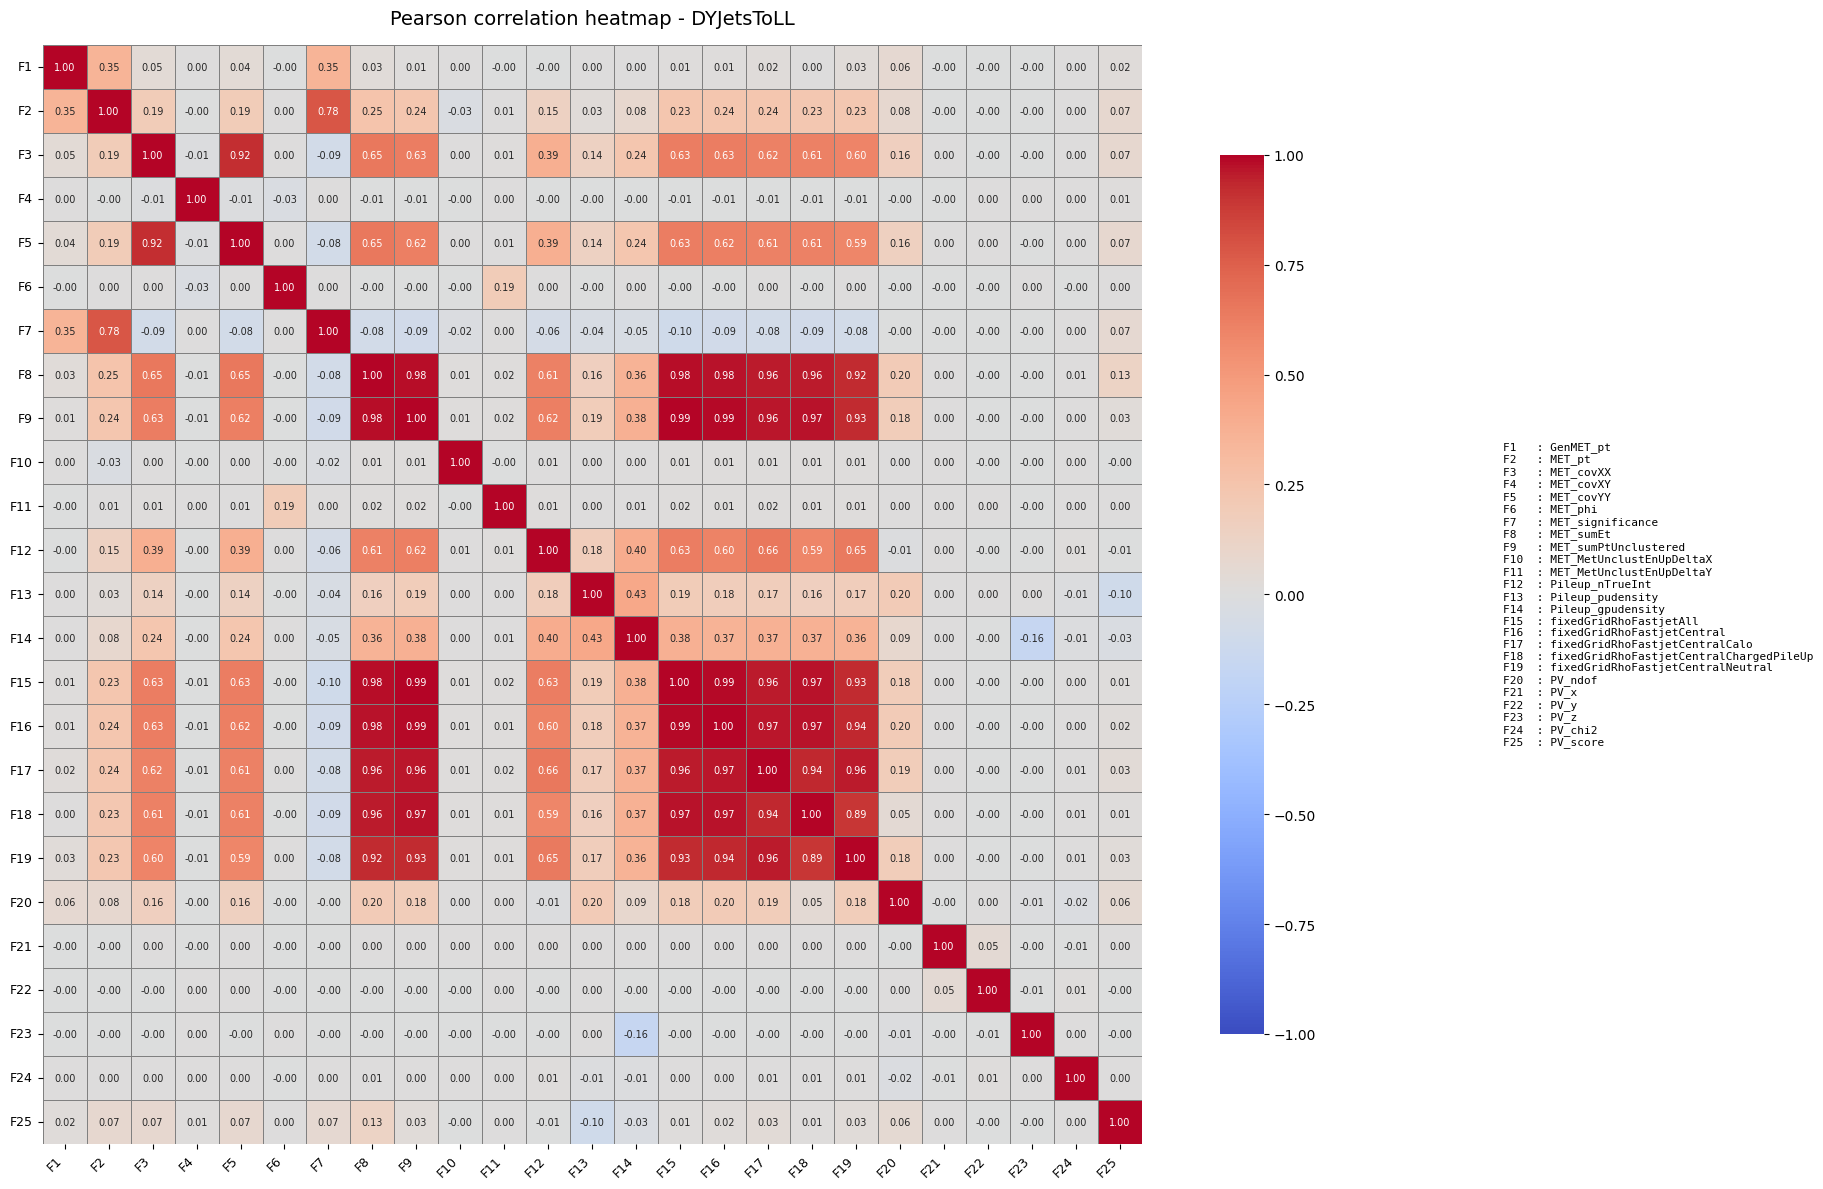

In [117]:
_correlation_heatmap(df, label)

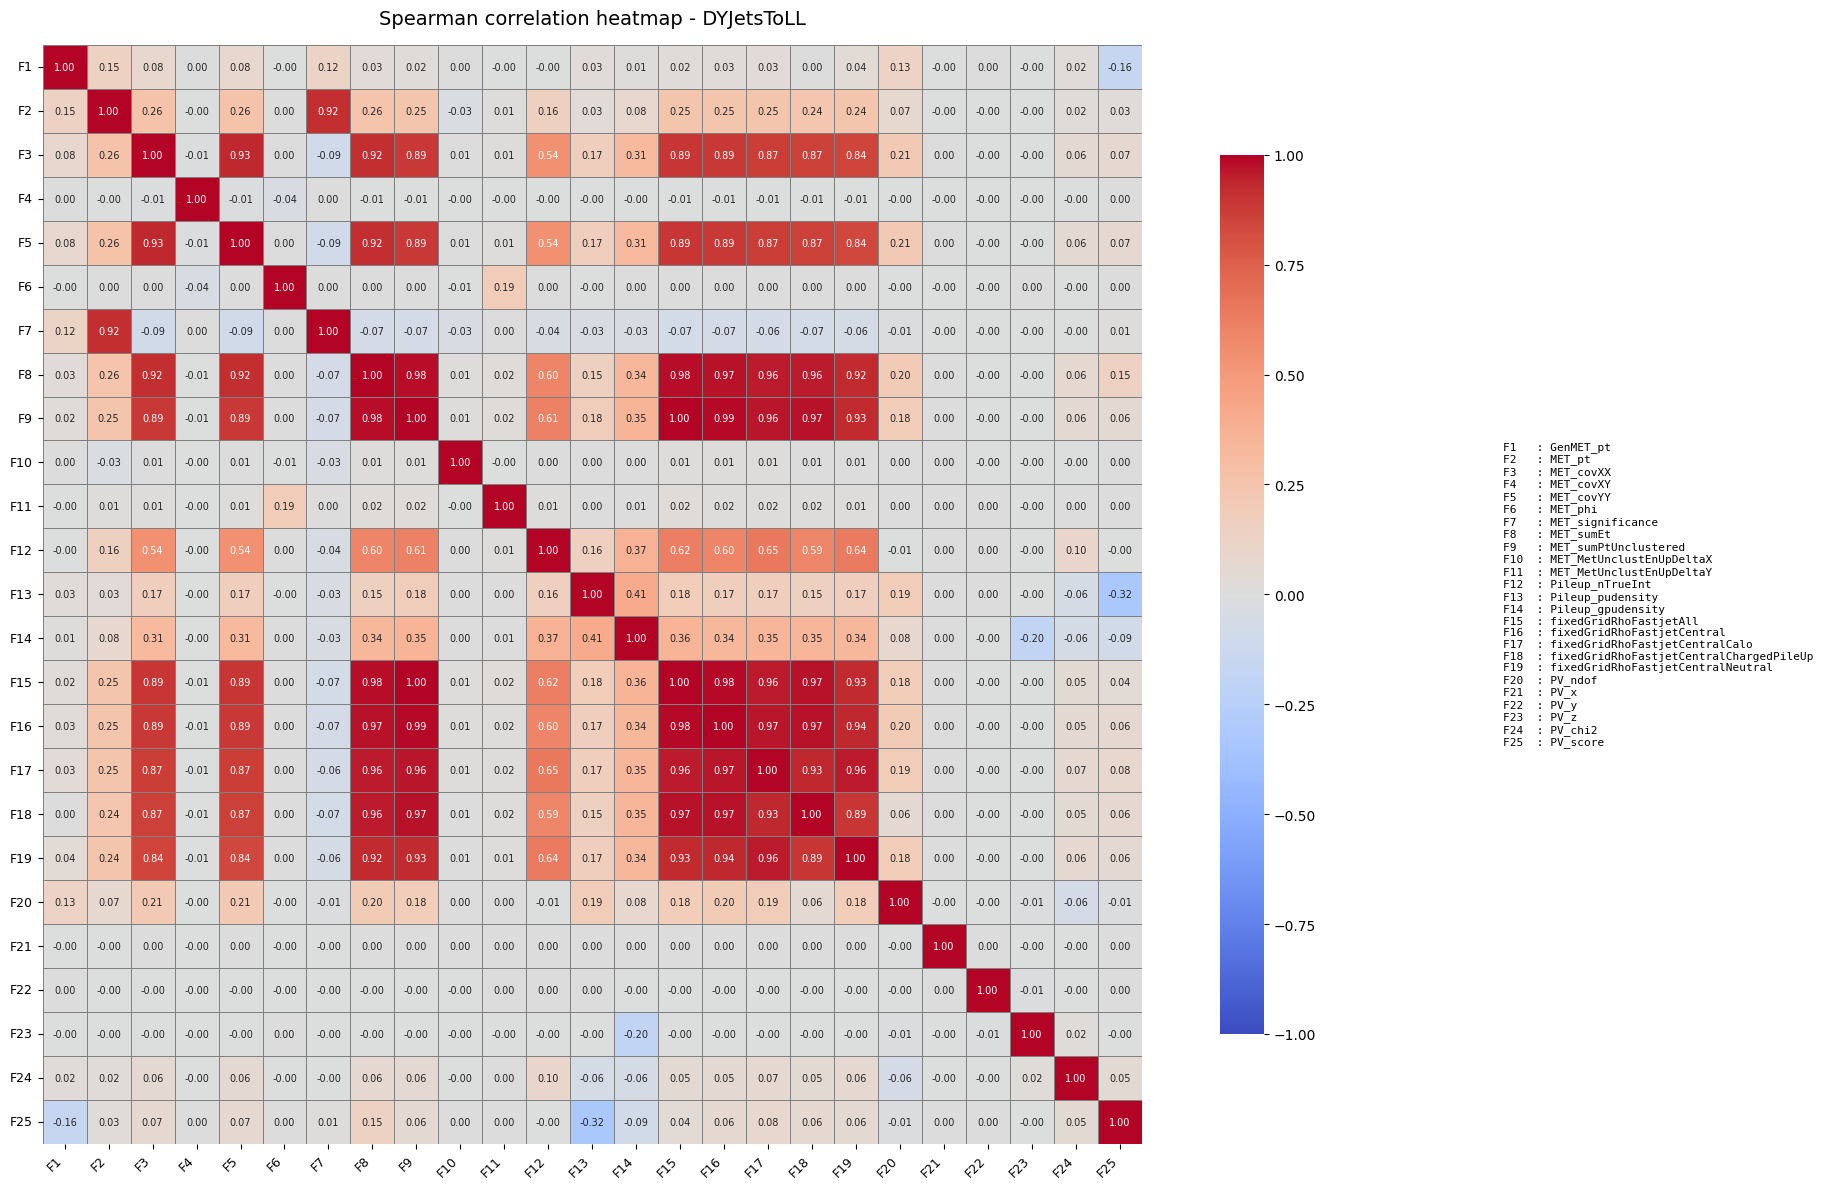

In [118]:
_correlation_heatmap(df, label, method="spearman")

Statistics for dataset DYJetsToLL:
    MET_pt:
count    1.257601e+06
mean     2.938182e+01
std      1.886534e+01
min      3.465150e-02
25%      1.603342e+01
50%      2.585431e+01
75%      3.863951e+01
max      5.862435e+02
Name: MET_pt, dtype: float64
    GenMET_pt:
count    1.257601e+06
mean     5.996480e+00
std      1.265850e+01
min      1.287165e-15
25%      1.413282e-07
50%      1.205131e-06
75%      6.847656e+00
max      5.120000e+02
Name: GenMET_pt, dtype: float64


/tmp/ipykernel_67856/2162679699.py:26: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/matilde/.local/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/matilde/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


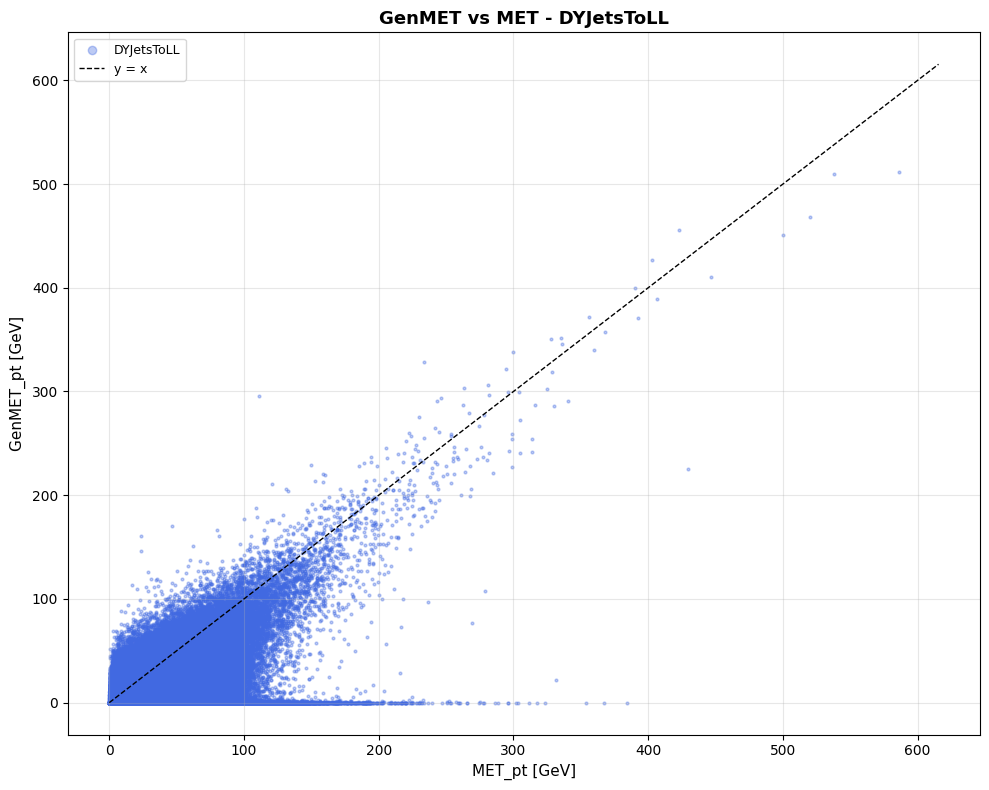

In [119]:
_scatterplot_MET(df, label=label, color=color)

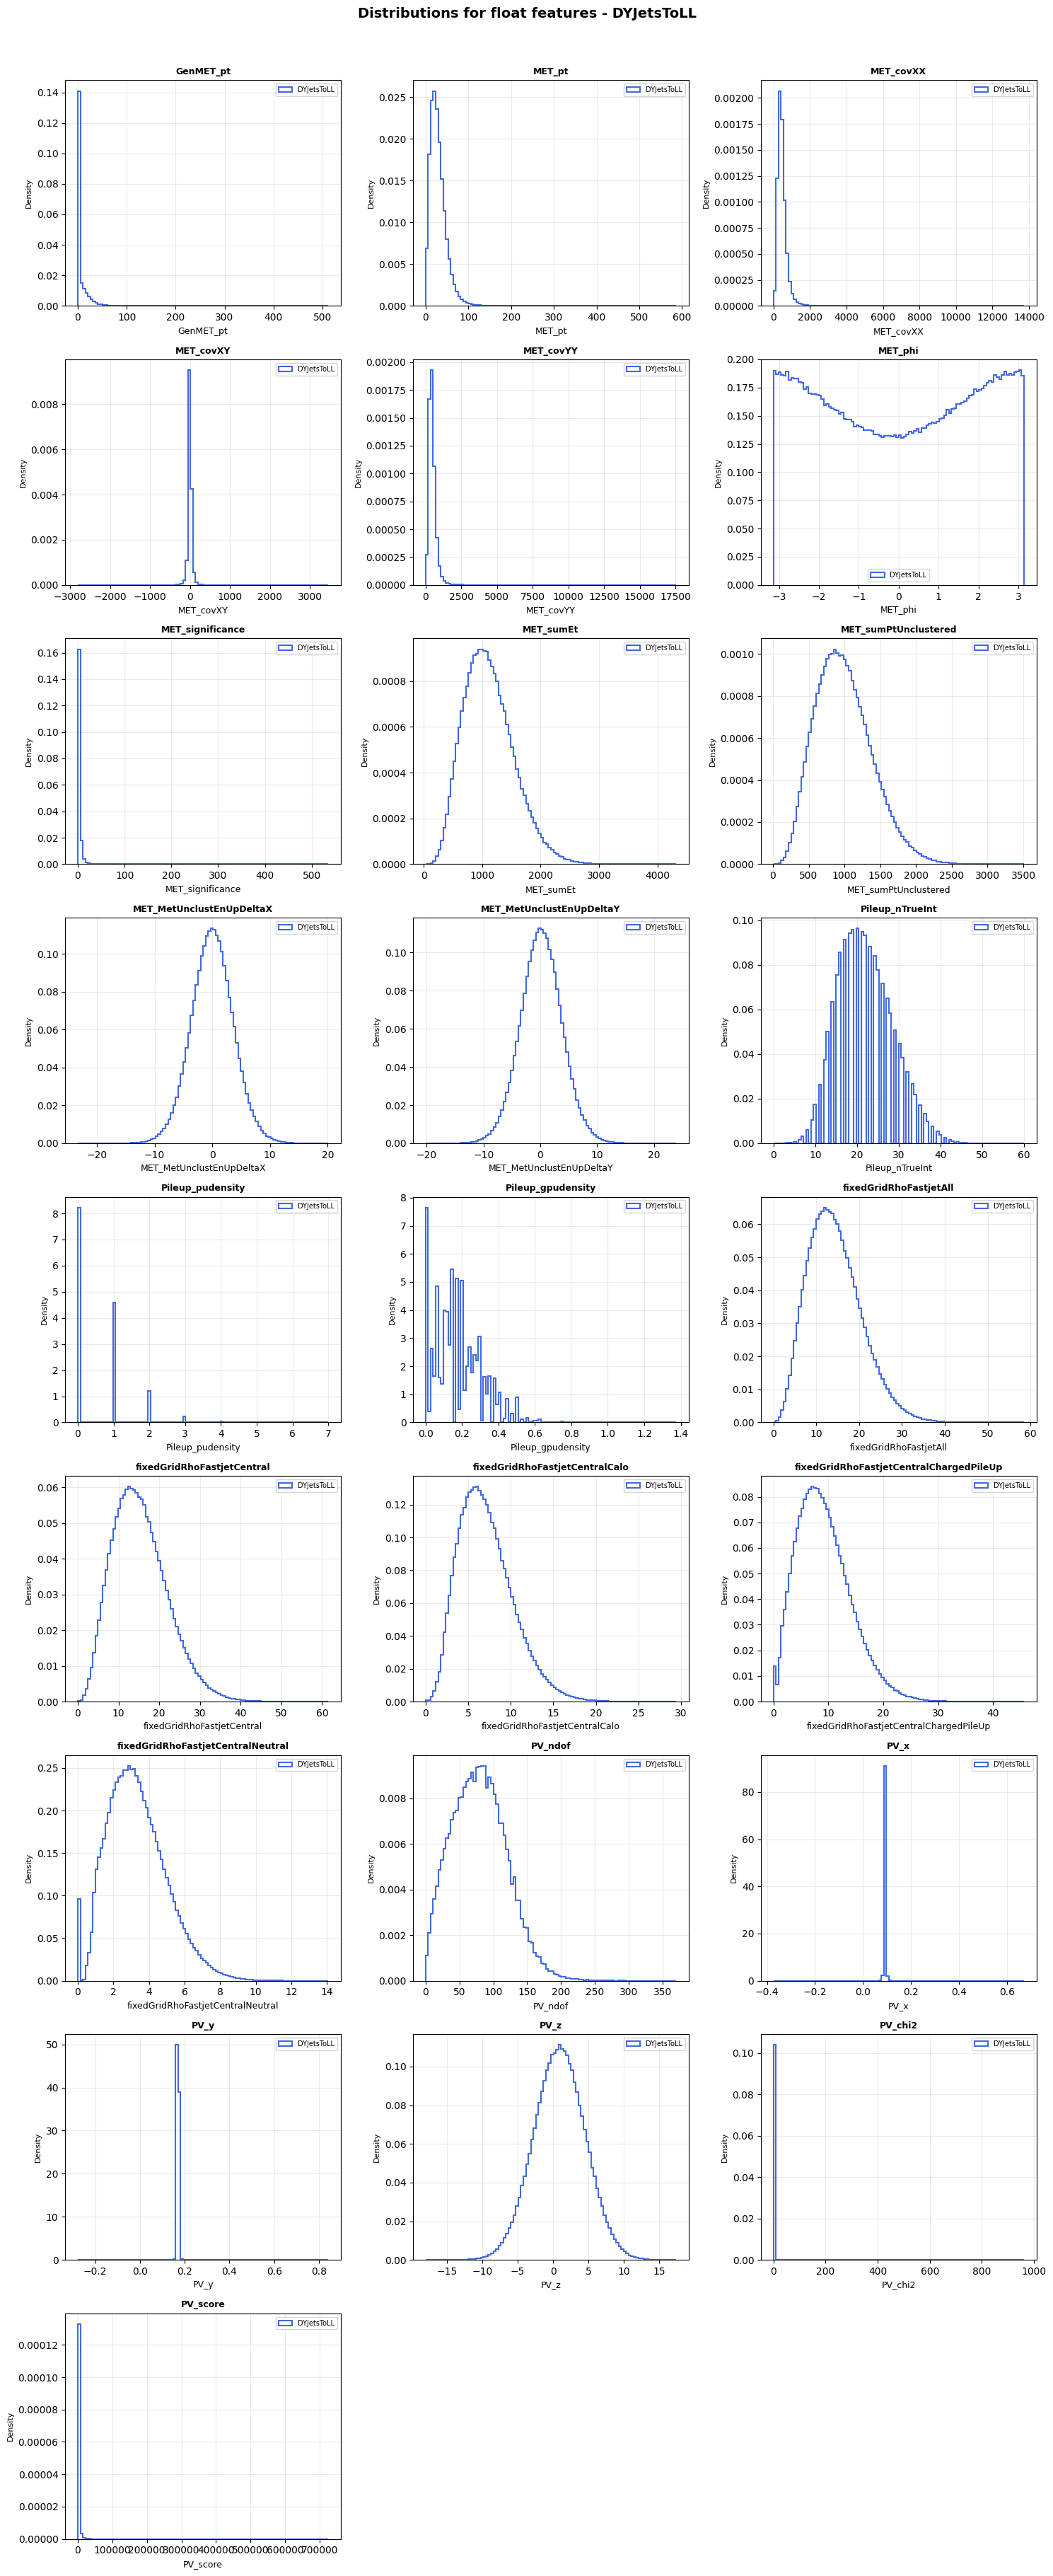

In [120]:
_data_distributions(df, label=label, color=color)

Outliers — DYJetsToLL
  GenMET_pt            159114 outliers (12.65%)
  MET_pt                34867 outliers (2.77%)
  MET_covXX             48285 outliers (3.84%)
  MET_covXY            129442 outliers (10.29%)
  MET_covYY             49140 outliers (3.91%)
  MET_phi                   0 outliers (0.00%)
  MET_significance      86634 outliers (6.89%)
  MET_sumEt             14008 outliers (1.11%)
  MET_sumPtUnclustered  12037 outliers (0.96%)
  MET_MetUnclustEnUpDeltaX  14818 outliers (1.18%)
  MET_MetUnclustEnUpDeltaY  14965 outliers (1.19%)
  Pileup_nTrueInt        8252 outliers (0.66%)
  Pileup_pudensity      23492 outliers (1.87%)
  Pileup_gpudensity     10644 outliers (0.85%)
  fixedGridRhoFastjetAll  14676 outliers (1.17%)
  fixedGridRhoFastjetCentral  14702 outliers (1.17%)
  fixedGridRhoFastjetCentralCalo  17623 outliers (1.40%)
  fixedGridRhoFastjetCentralChargedPileUp  16951 outliers (1.35%)
  fixedGridRhoFastjetCentralNeutral  14650 outliers (1.16%)
  PV_ndof                

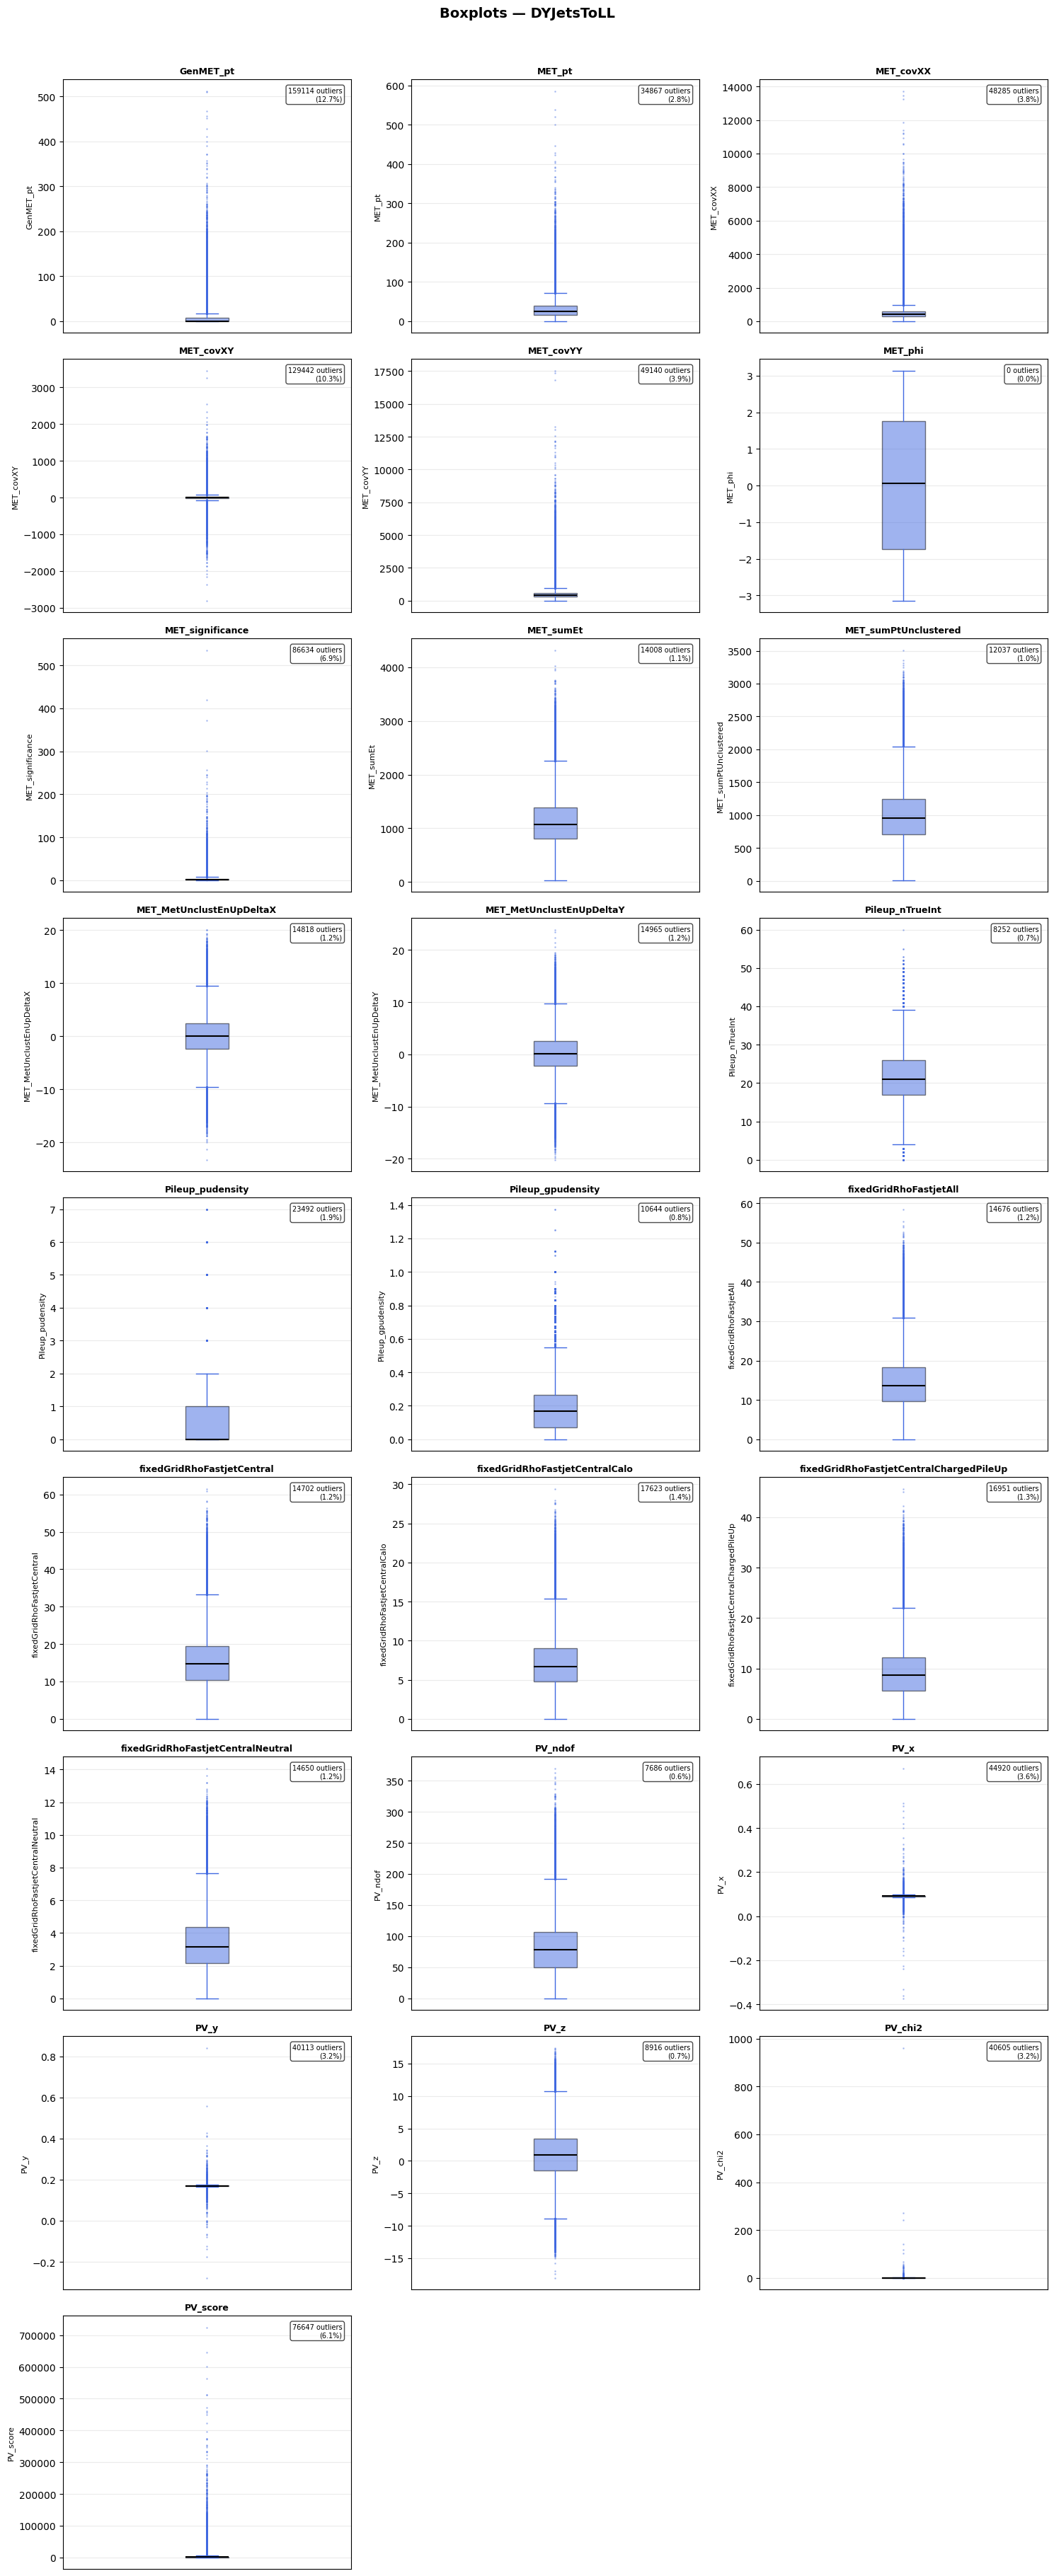

In [121]:
_boxplots(df, label=label, color=color)

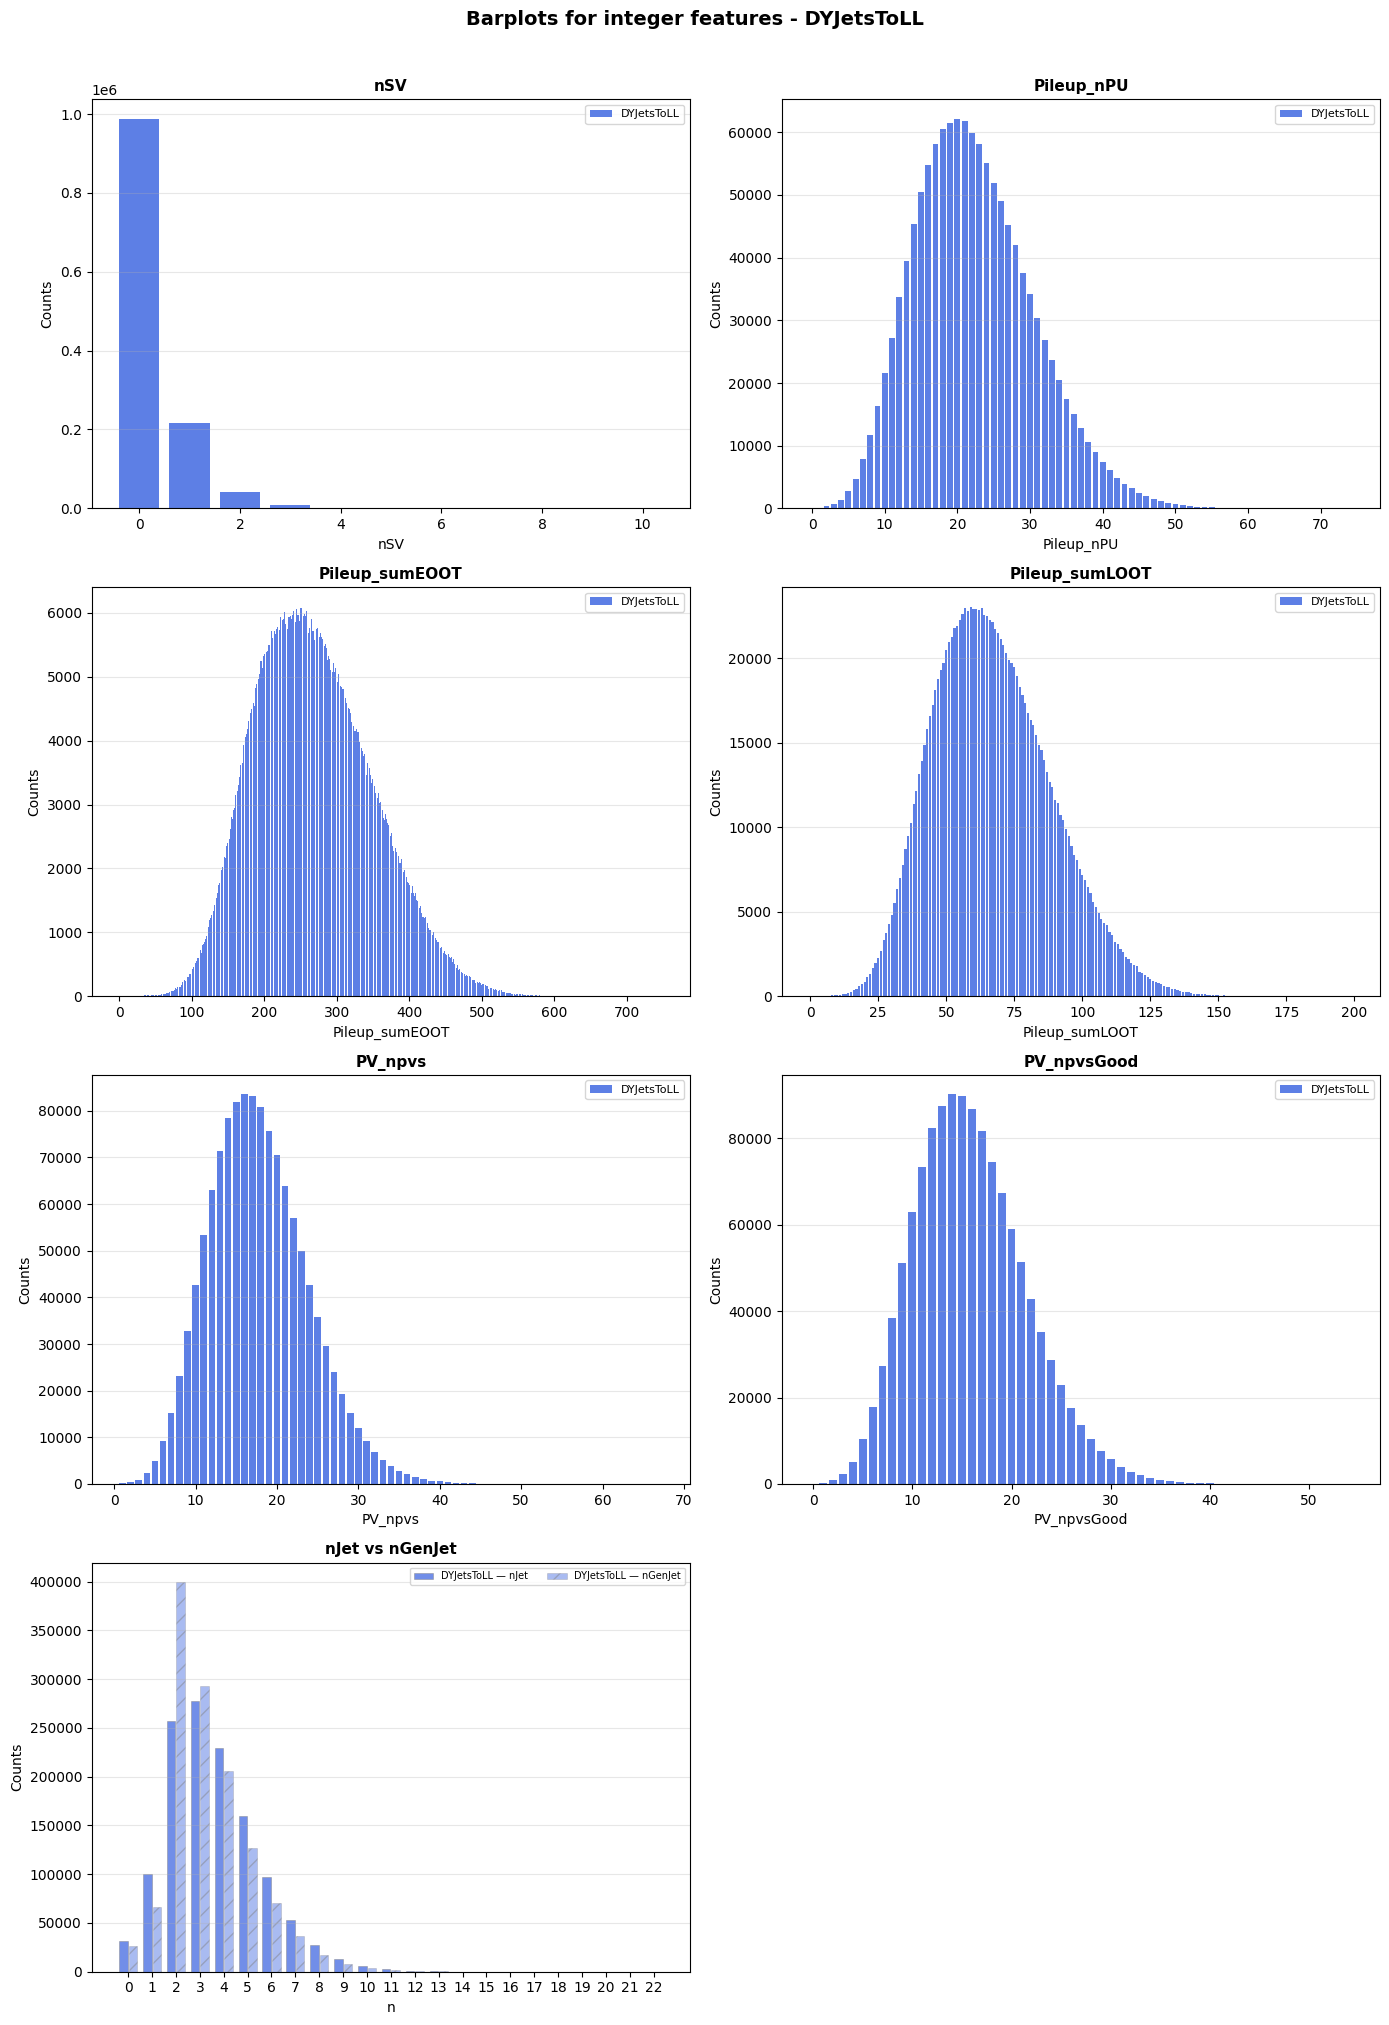

In [122]:
_data_barplots(df, label=label, color=color)

---

## HToAATo2Mu2B Dataset

In this process, a Higgs boson decays into a pair of light pseudoscalar particles, each of which subsequently decays into either a pair of muons or a pair of b-quarks.

From this dataset we expect:
- lower values of `MET_pt`, since neutrinos are not part of the decay chain and any observed MET is primarily due to pile-up and detector effects;
- events containing pairs of muons and b-jets;
- a significant number of secondary vertices, arising from the displaced decays of the b-hadrons.

This dataset, while well motivated, presents a greater challenge for machine learning. The decay chain involves a relatively large number of final state particles, each contributing its own set of observable features. Unlike the ZZTo2L2Nu case, where MET has a clear physical origin, here the MET signal is weak and dominated by instrumental effects, making it harder for the model to find a meaningful pattern. This makes the HToAATo2Mu2B process a useful stress test for evaluating the robustness and generalization of the trained model.

In [123]:
label = list(DATASETS.items())[1][0]
path = DATASETS.get("HToAATo2Mu2B")
color = PALETTE[1]

df = _load_dataset(path, TREE_NAME)
print(f"Dataset {label}:")
print(f"    {df.shape[1]} features x {df.shape[0]} events")

Dataset HToAATo2Mu2B:
    33 features x 200000 events


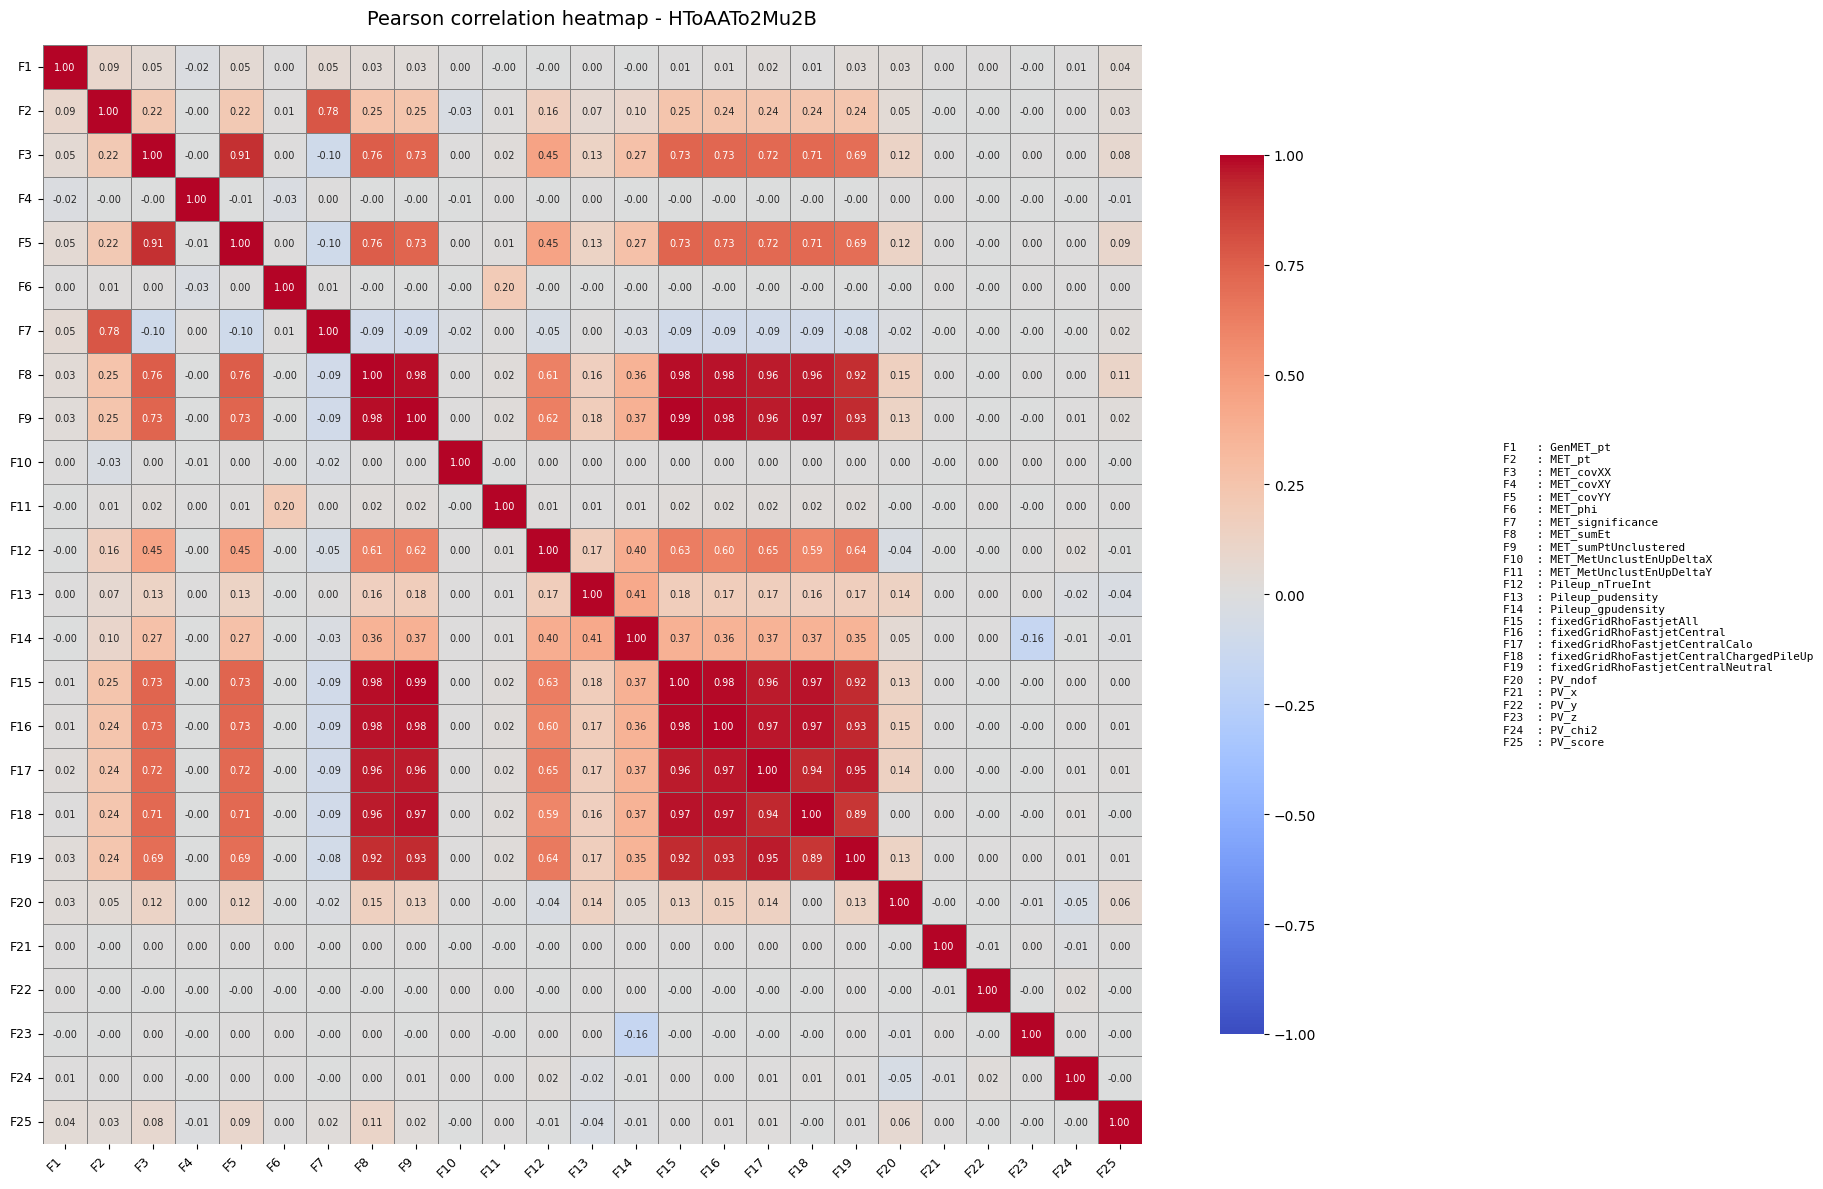

In [124]:
_correlation_heatmap(df, label)

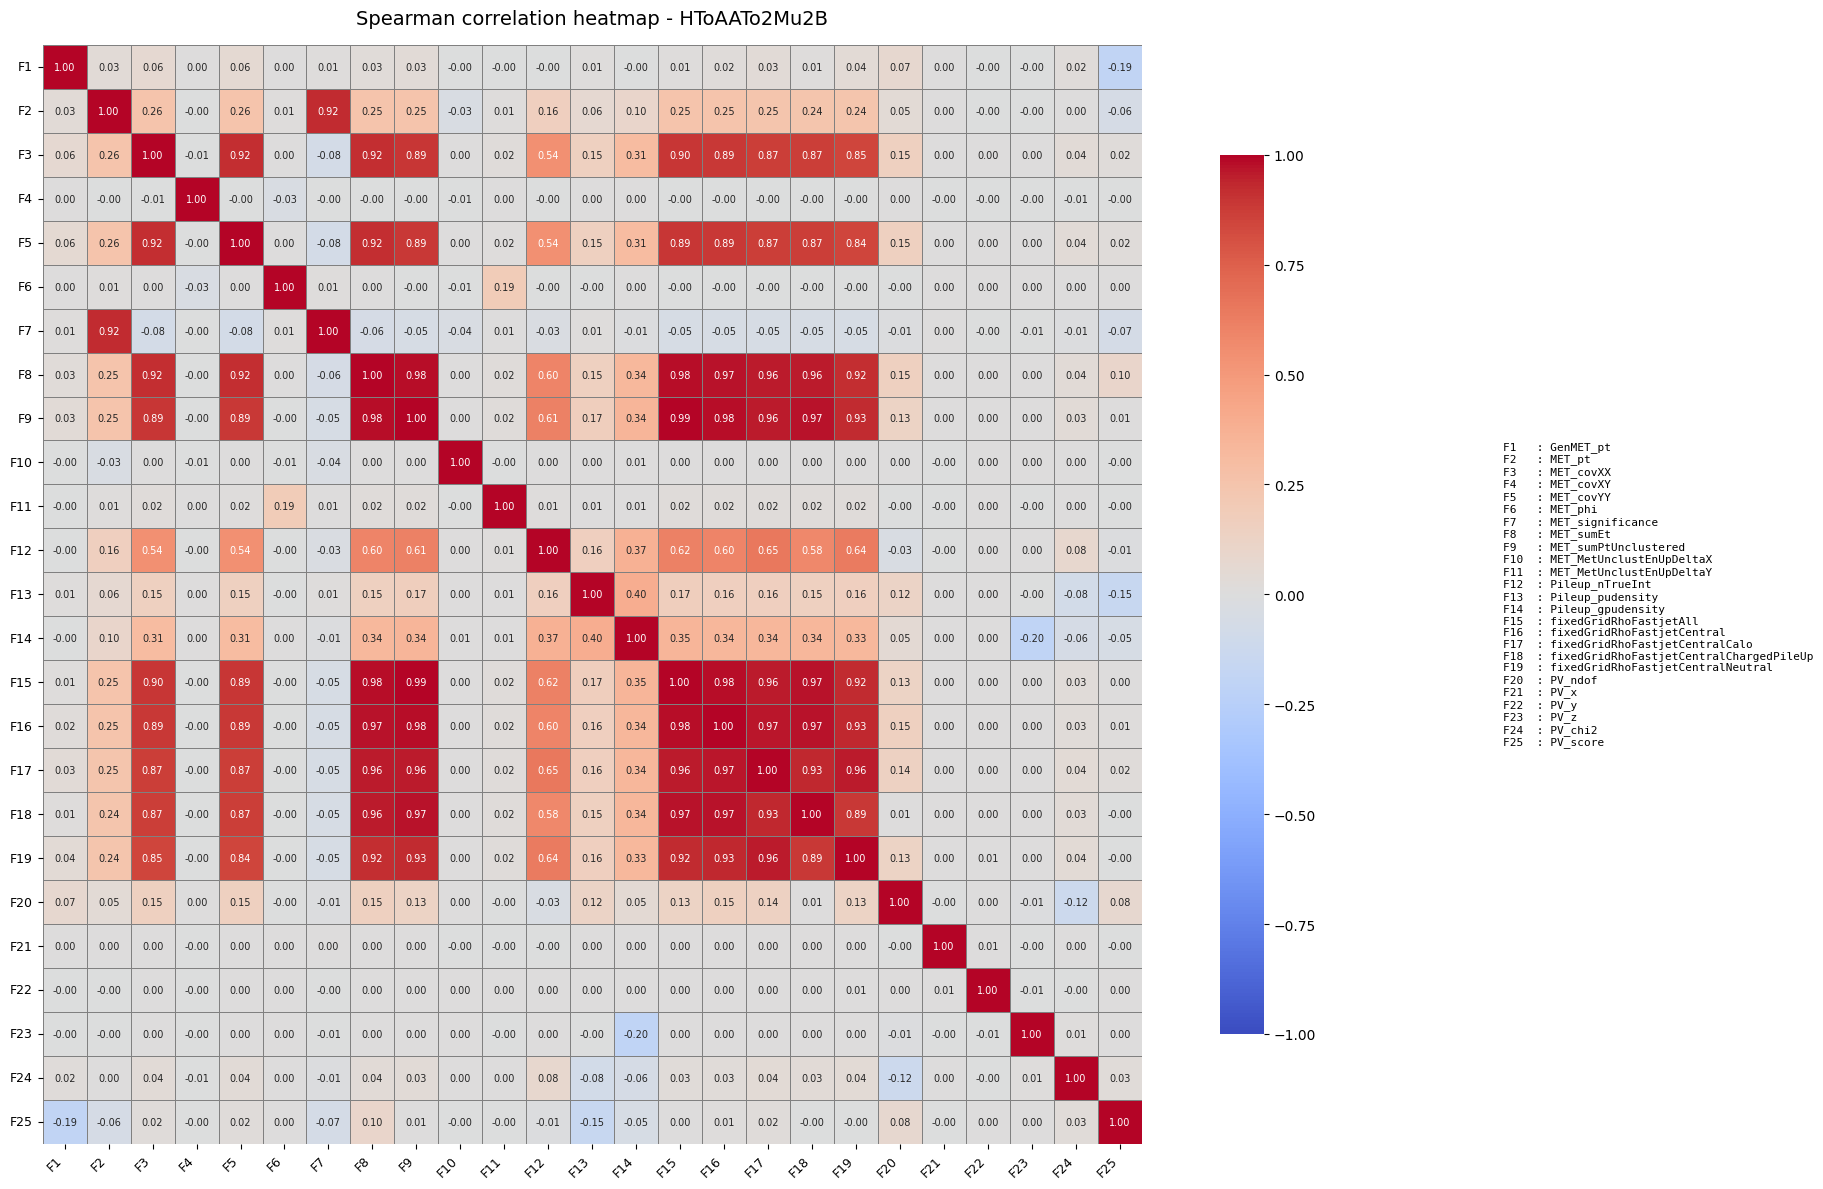

In [125]:
_correlation_heatmap(df, label, method="spearman")

Statistics for dataset HToAATo2Mu2B:
    MET_pt:
count    200000.000000
mean         28.771740
std          17.961229
min           0.060027
25%          15.836837
50%          25.457947
75%          37.923629
max         358.427490
Name: MET_pt, dtype: float64
    GenMET_pt:
count    2.000000e+05
mean     4.262918e+00
std      6.550319e+00
min      1.417616e-14
25%      3.250534e-09
50%      1.532227e+00
75%      6.105469e+00
max      2.945000e+02
Name: GenMET_pt, dtype: float64


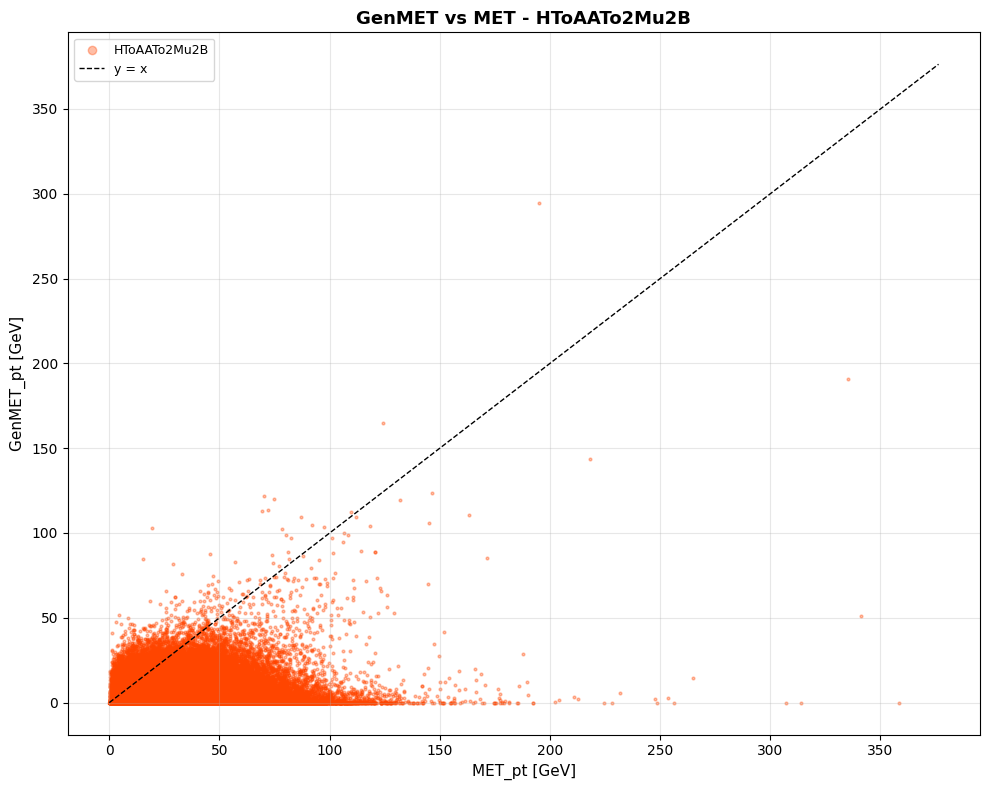

In [126]:
_scatterplot_MET(df, label=label, color=color)

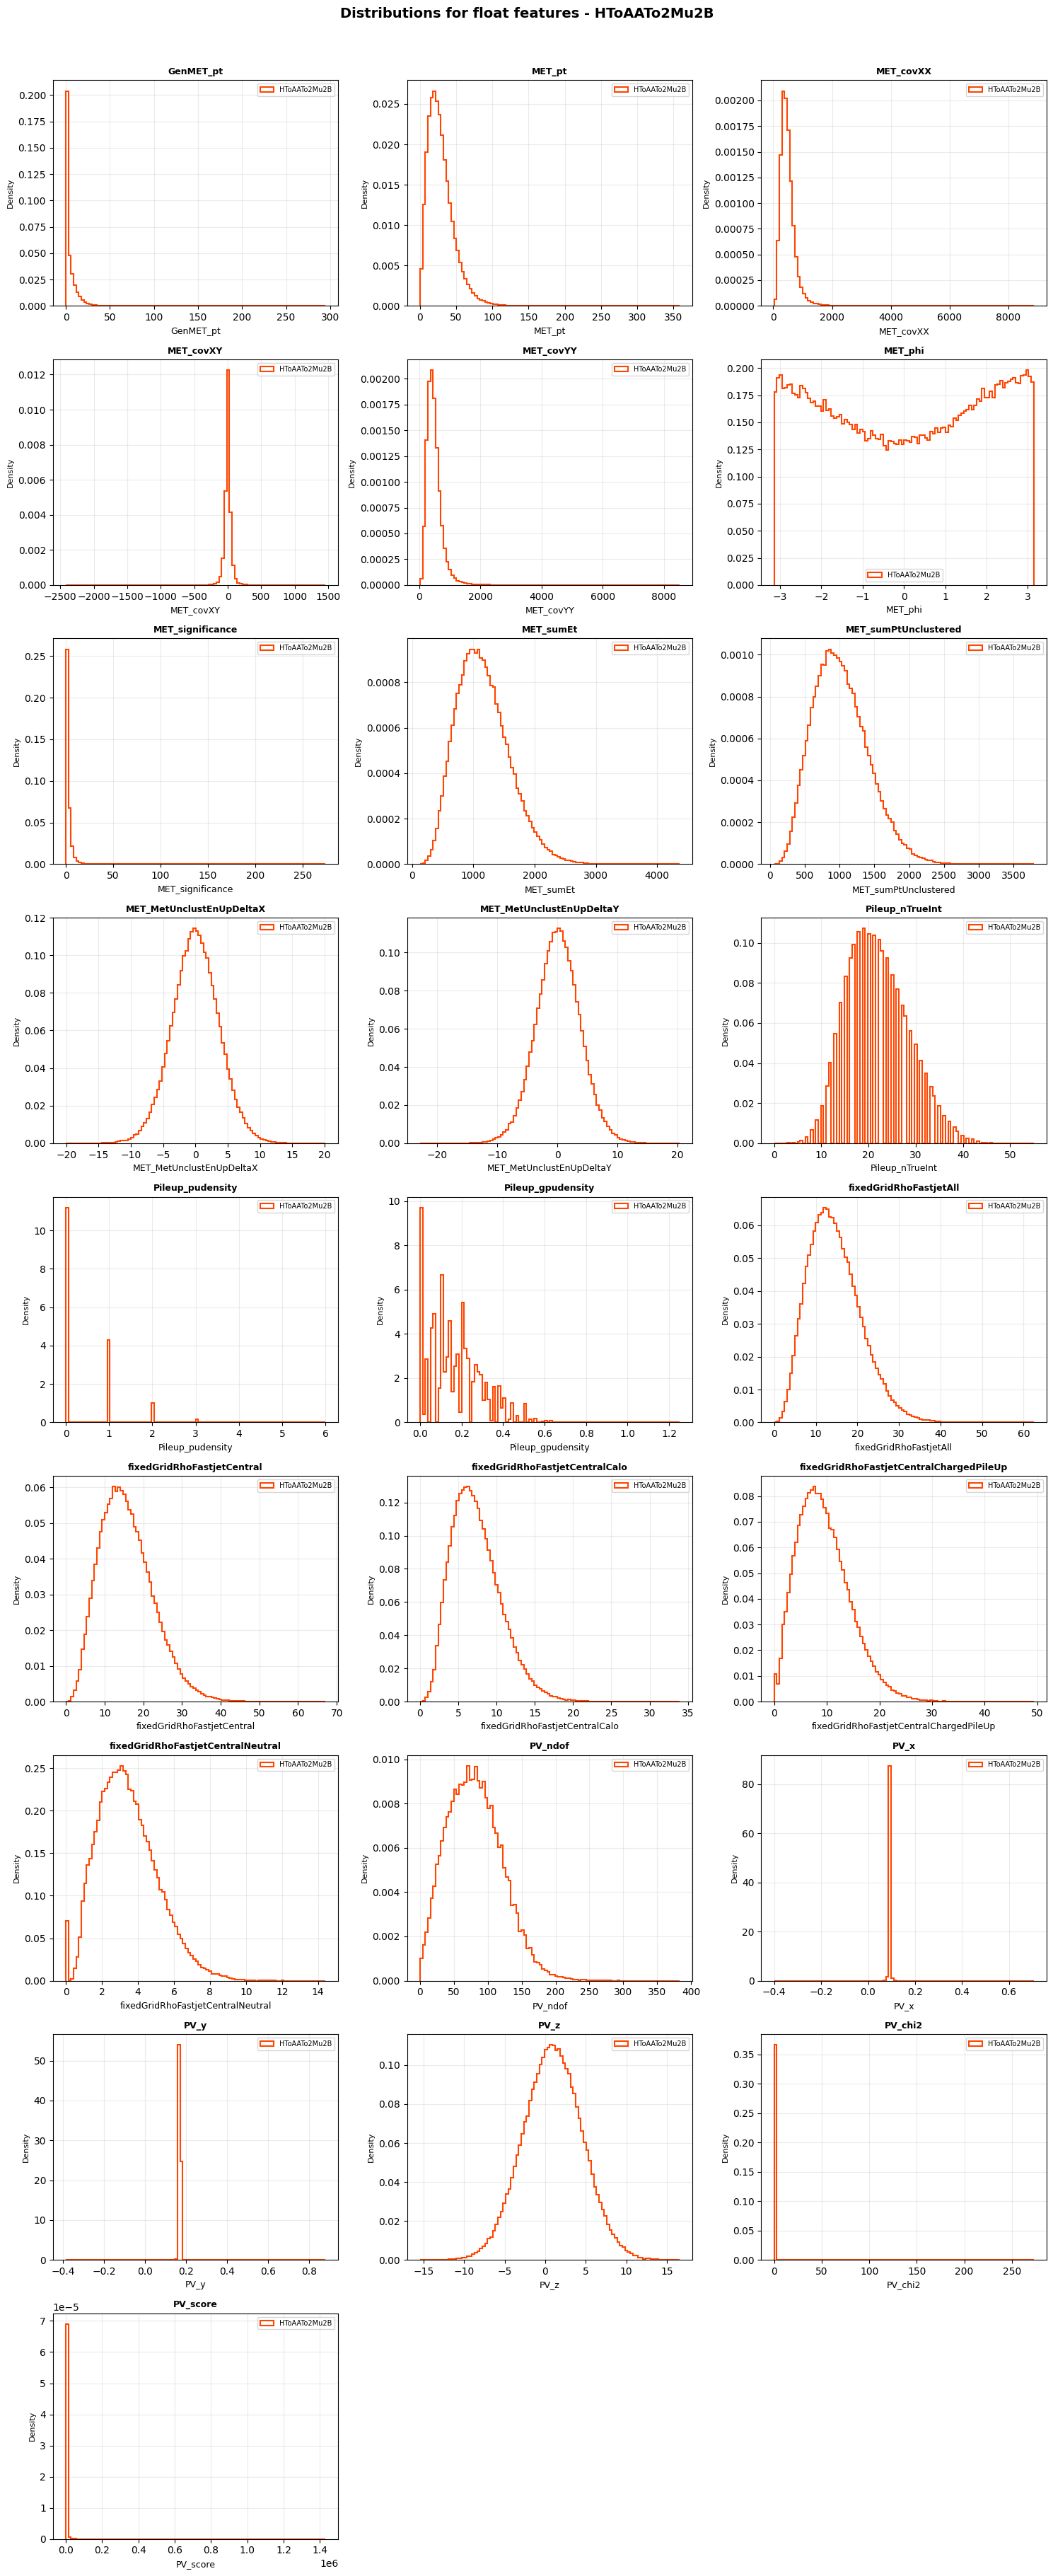

In [127]:
_data_distributions(df, label=label, color=color)

Outliers — HToAATo2Mu2B
  GenMET_pt             13044 outliers (6.52%)
  MET_pt                 5393 outliers (2.70%)
  MET_covXX              7180 outliers (3.59%)
  MET_covXY             15720 outliers (7.86%)
  MET_covYY              7316 outliers (3.66%)
  MET_phi                   0 outliers (0.00%)
  MET_significance      13876 outliers (6.94%)
  MET_sumEt              2211 outliers (1.11%)
  MET_sumPtUnclustered   1908 outliers (0.95%)
  MET_MetUnclustEnUpDeltaX   2219 outliers (1.11%)
  MET_MetUnclustEnUpDeltaY   2352 outliers (1.18%)
  Pileup_nTrueInt        1252 outliers (0.63%)
  Pileup_pudensity       2375 outliers (1.19%)
  Pileup_gpudensity      1735 outliers (0.87%)
  fixedGridRhoFastjetAll   2296 outliers (1.15%)
  fixedGridRhoFastjetCentral   2330 outliers (1.17%)
  fixedGridRhoFastjetCentralCalo   2832 outliers (1.42%)
  fixedGridRhoFastjetCentralChargedPileUp   2638 outliers (1.32%)
  fixedGridRhoFastjetCentralNeutral   2339 outliers (1.17%)
  PV_ndof                

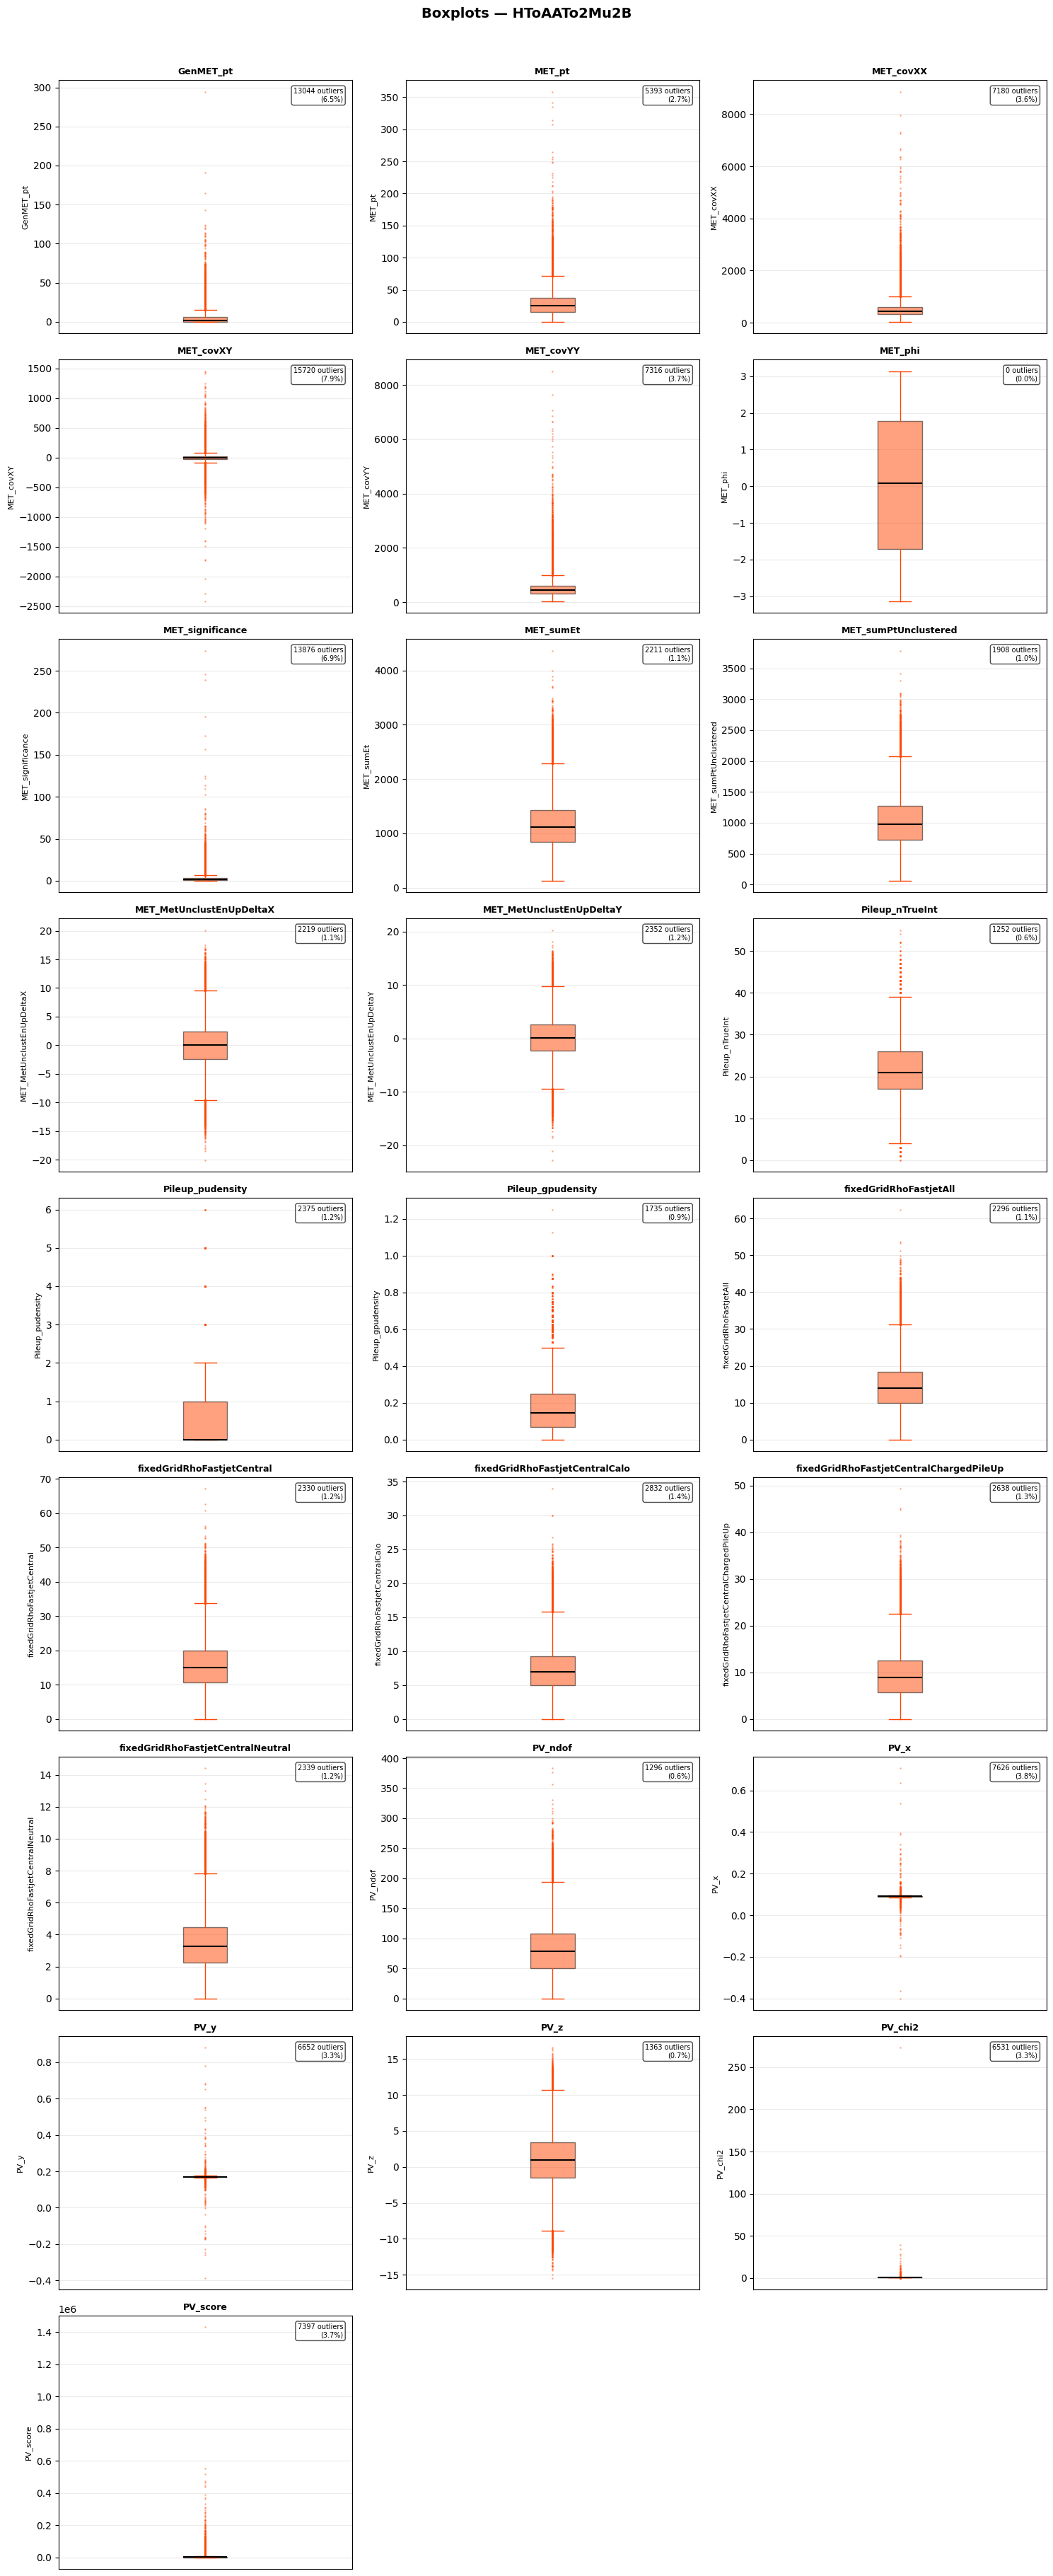

In [128]:
_boxplots(df, label=label, color=color)

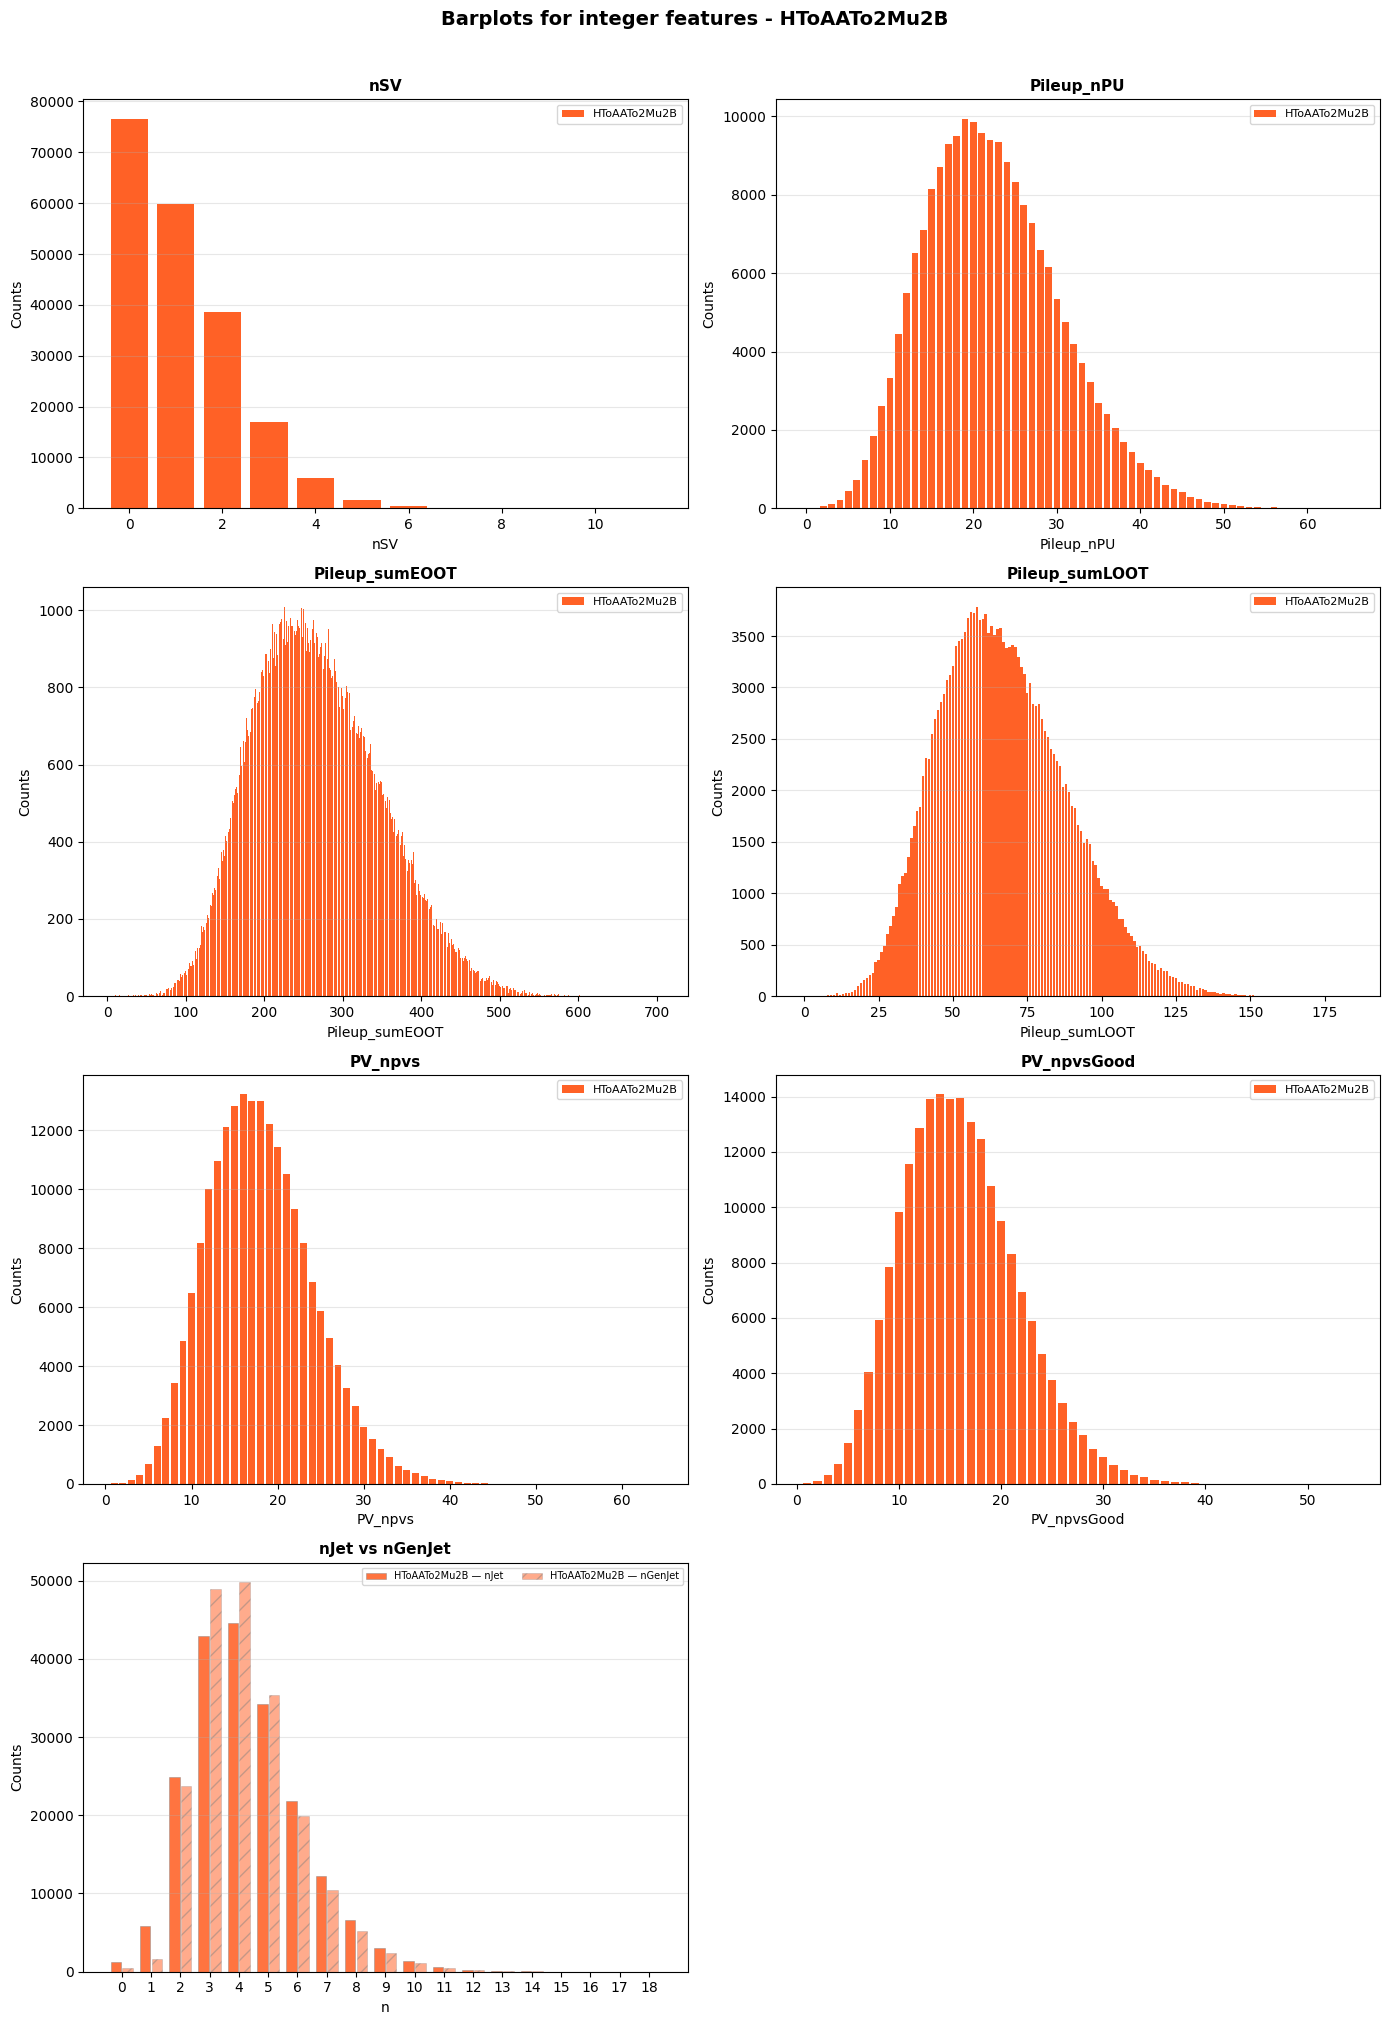

In [129]:
_data_barplots(df, label=label, color=color)

As visible in the `MET_pt vs GenMET_pt` plot, the reconstructed MET poorly tracks the generator level MET for this process, confirming that the detector is not sensitive enough to the actual missing energy involved. This motivates the use of additional, more discriminating features rather than relying on `MET_pt` alone.

---

## ZZTo2L2Nu dataset

In this event a pair of Z bosons decays into a pair of leptons and a pair of neutrinos. The MET values are primarily due to the neutrinos, which are invisible to the detector: MET is the only observable that can indirectly signal their presence.

Given the underlying physics of this proccess, we expect:
- higher values of `MET_pt`;
- events containing either 2 electrons or 2 muons;
- no significant jet activity (jets that do appear are likely due to secondary processes);
- no significant number of secondary vertices.


This dataset was chosen because the physics process is well understood and the observed MET is most likely genuine, i.e. directly attributable to the neutrinos produced in the decay, making it a reliable starting point for the analysis.

In [130]:
label = list(DATASETS.items())[2][0]
path = DATASETS.get("ZZTo2L2Nu")
color = PALETTE[2]

df = _load_dataset(path, TREE_NAME)
print(f"Dataset {label}:")
print(f"    {df.shape[1]} features x {df.shape[0]} events")

Dataset ZZTo2L2Nu:
    33 features x 1285000 events


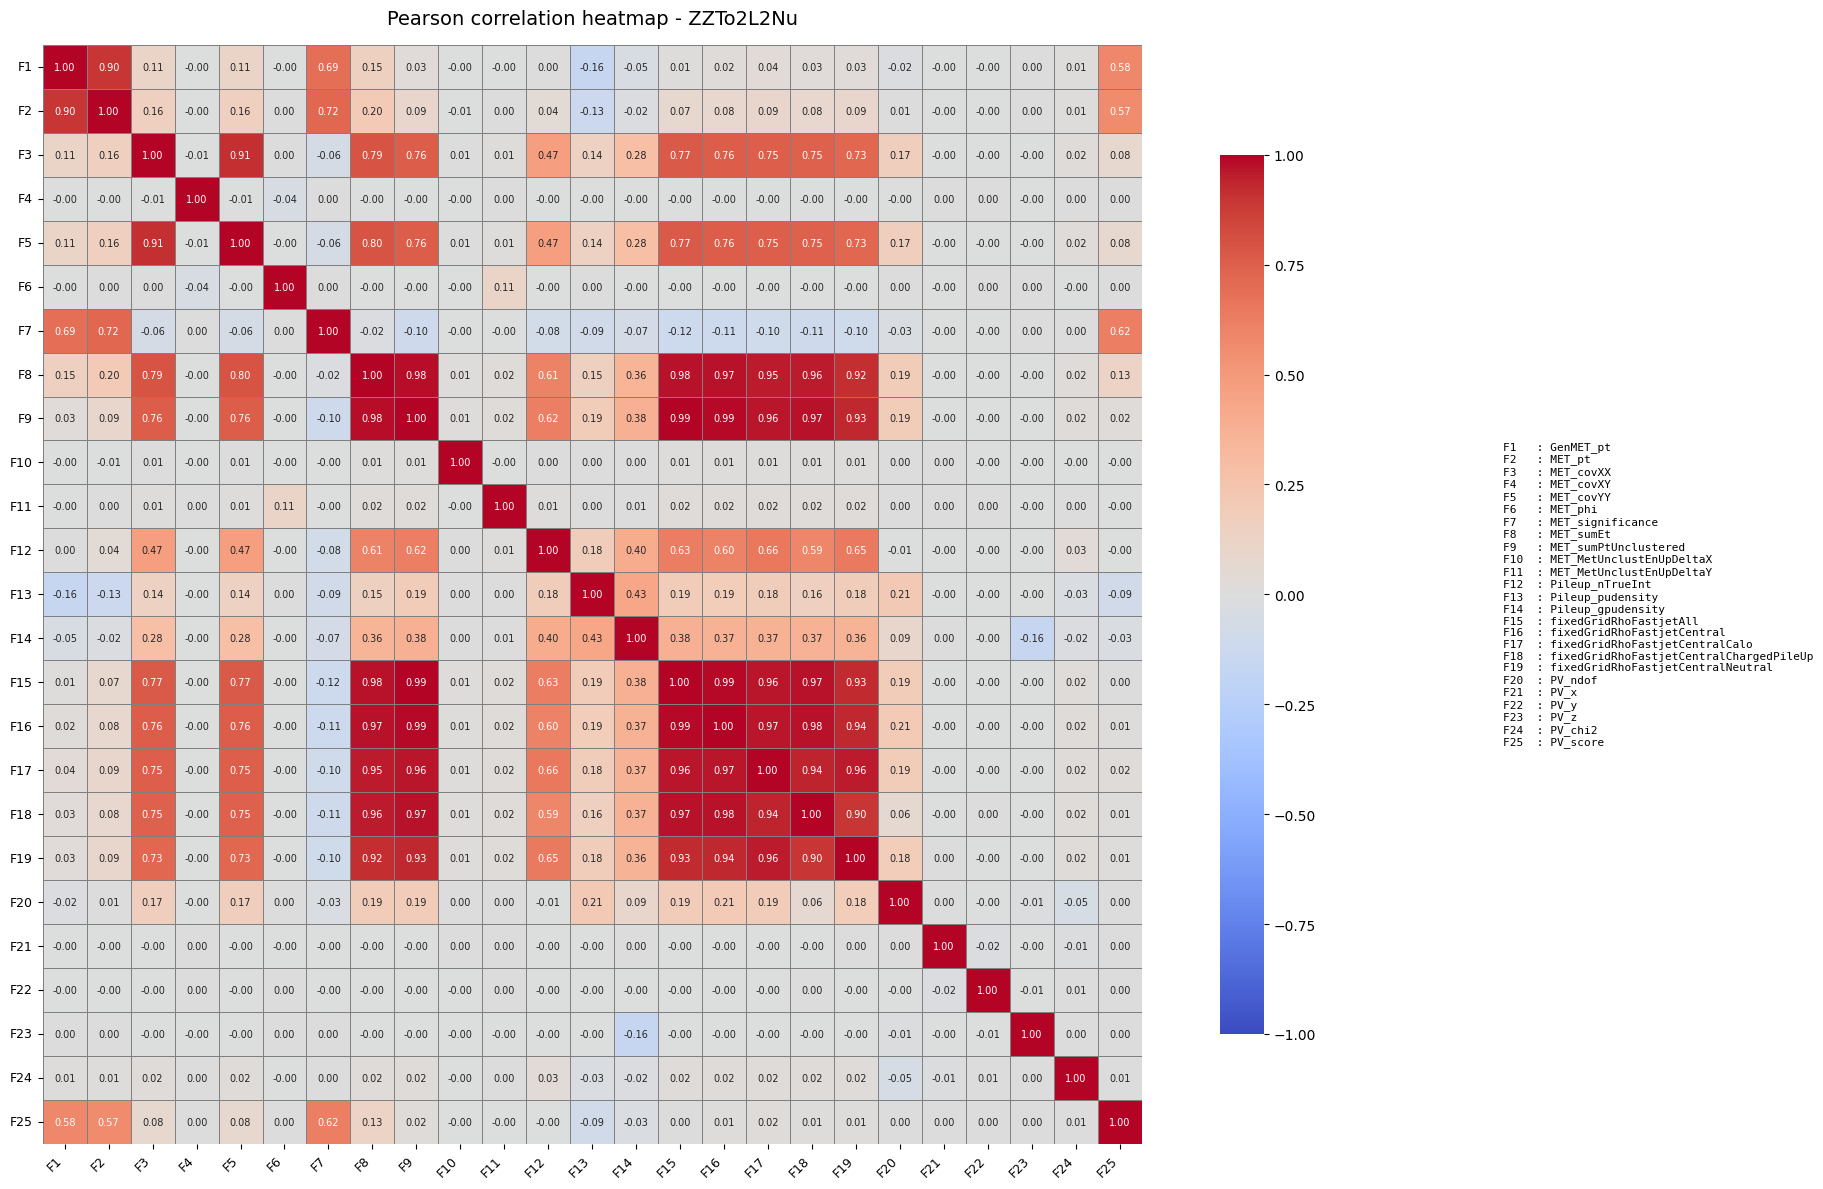

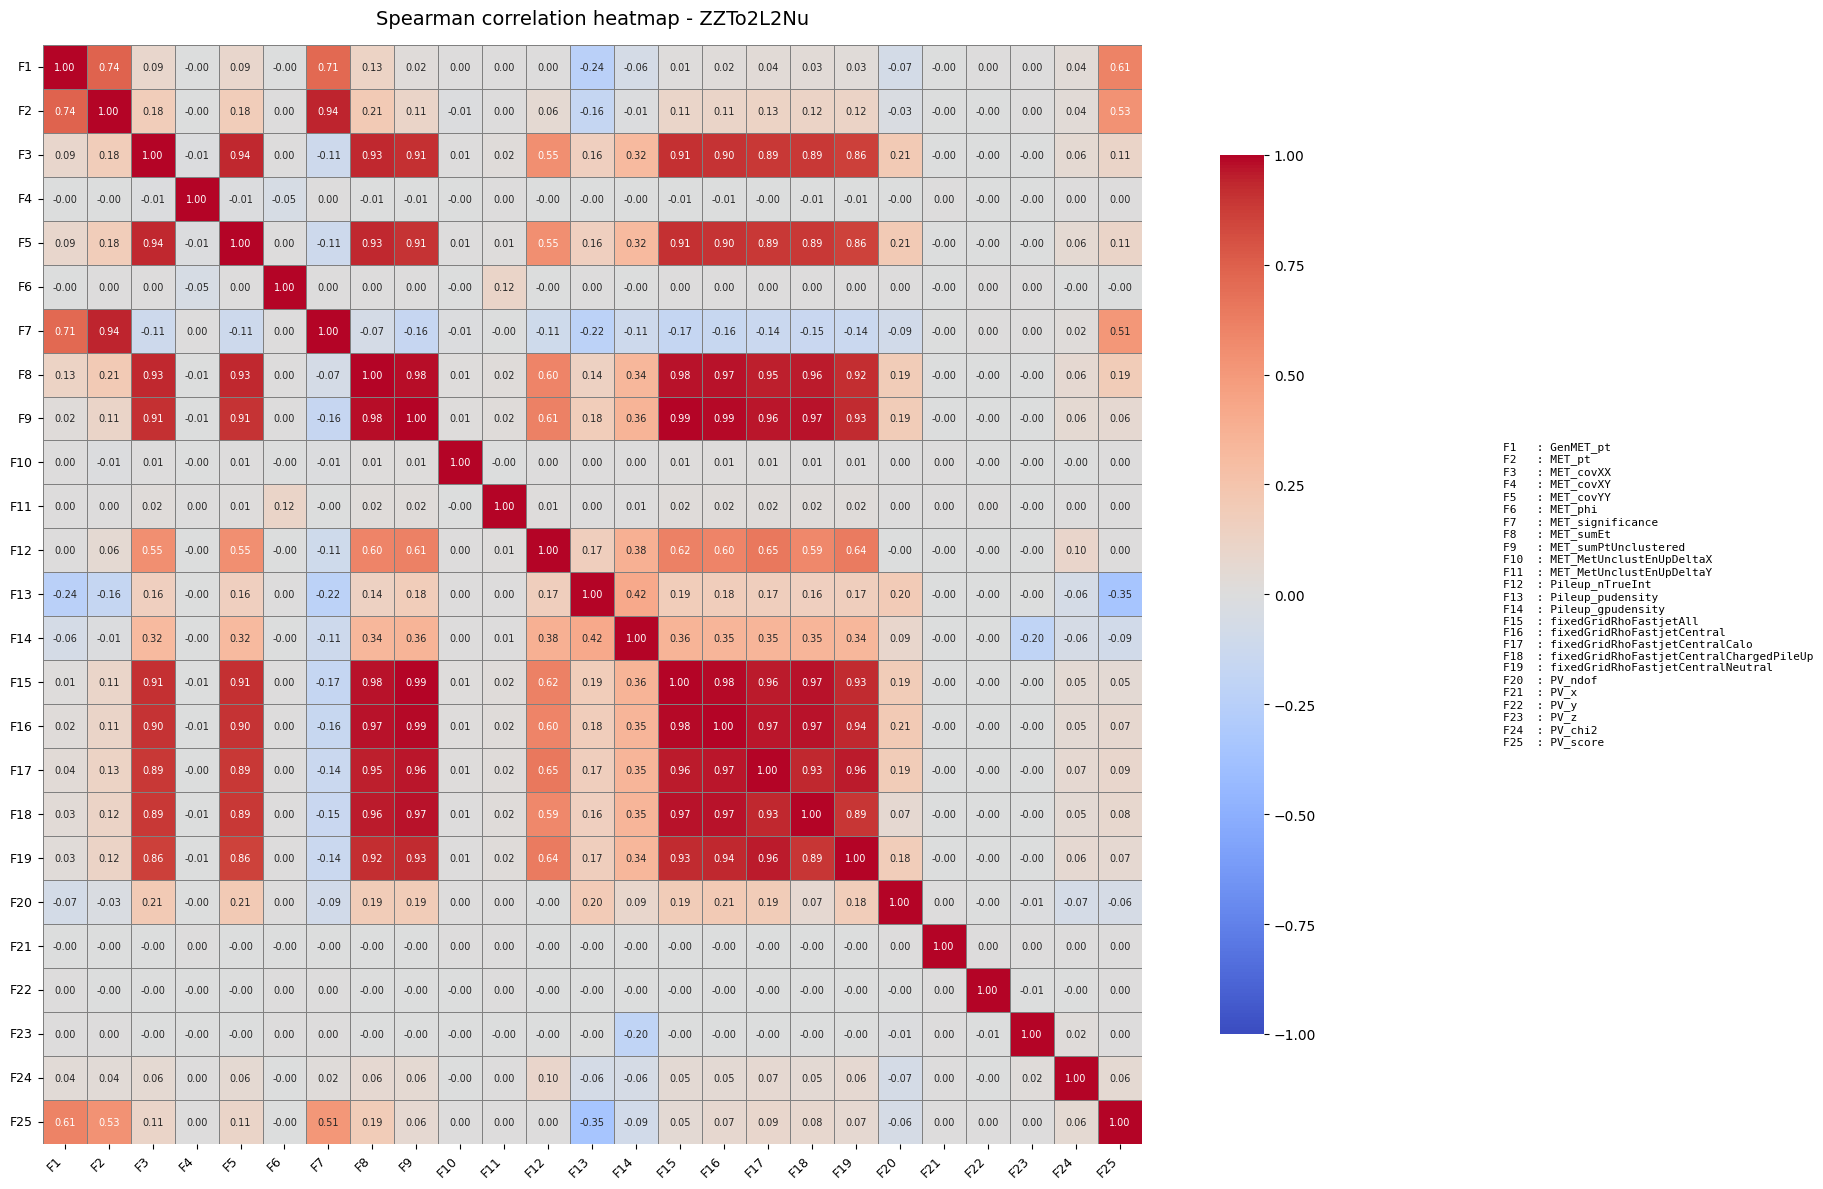

Statistics for dataset ZZTo2L2Nu:
    MET_pt:
count    1.285000e+06
mean     5.431593e+01
std      4.683481e+01
min      2.039826e-02
25%      2.488871e+01
50%      4.241247e+01
75%      6.908311e+01
max      1.463373e+03
Name: MET_pt, dtype: float64
    GenMET_pt:
count    1.285000e+06
mean     4.669128e+01
std      4.650320e+01
min      1.669312e-02
25%      1.707812e+01
50%      3.384375e+01
75%      6.065625e+01
max      1.627000e+03
Name: GenMET_pt, dtype: float64


/tmp/ipykernel_67856/2162679699.py:26: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/matilde/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


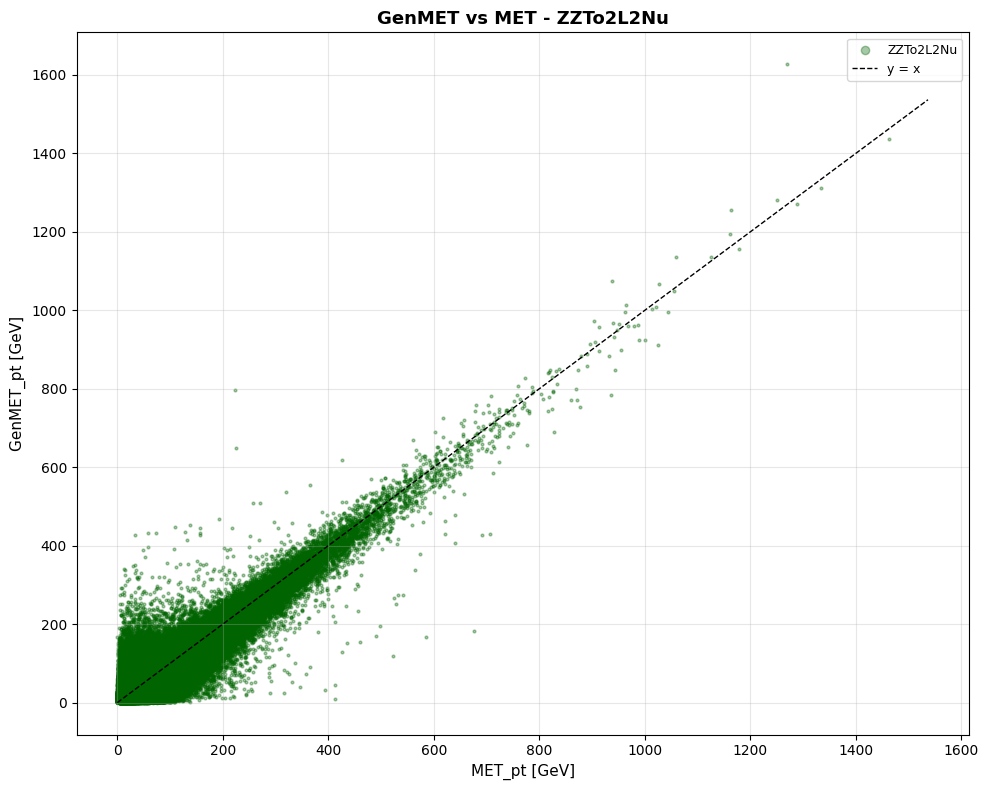

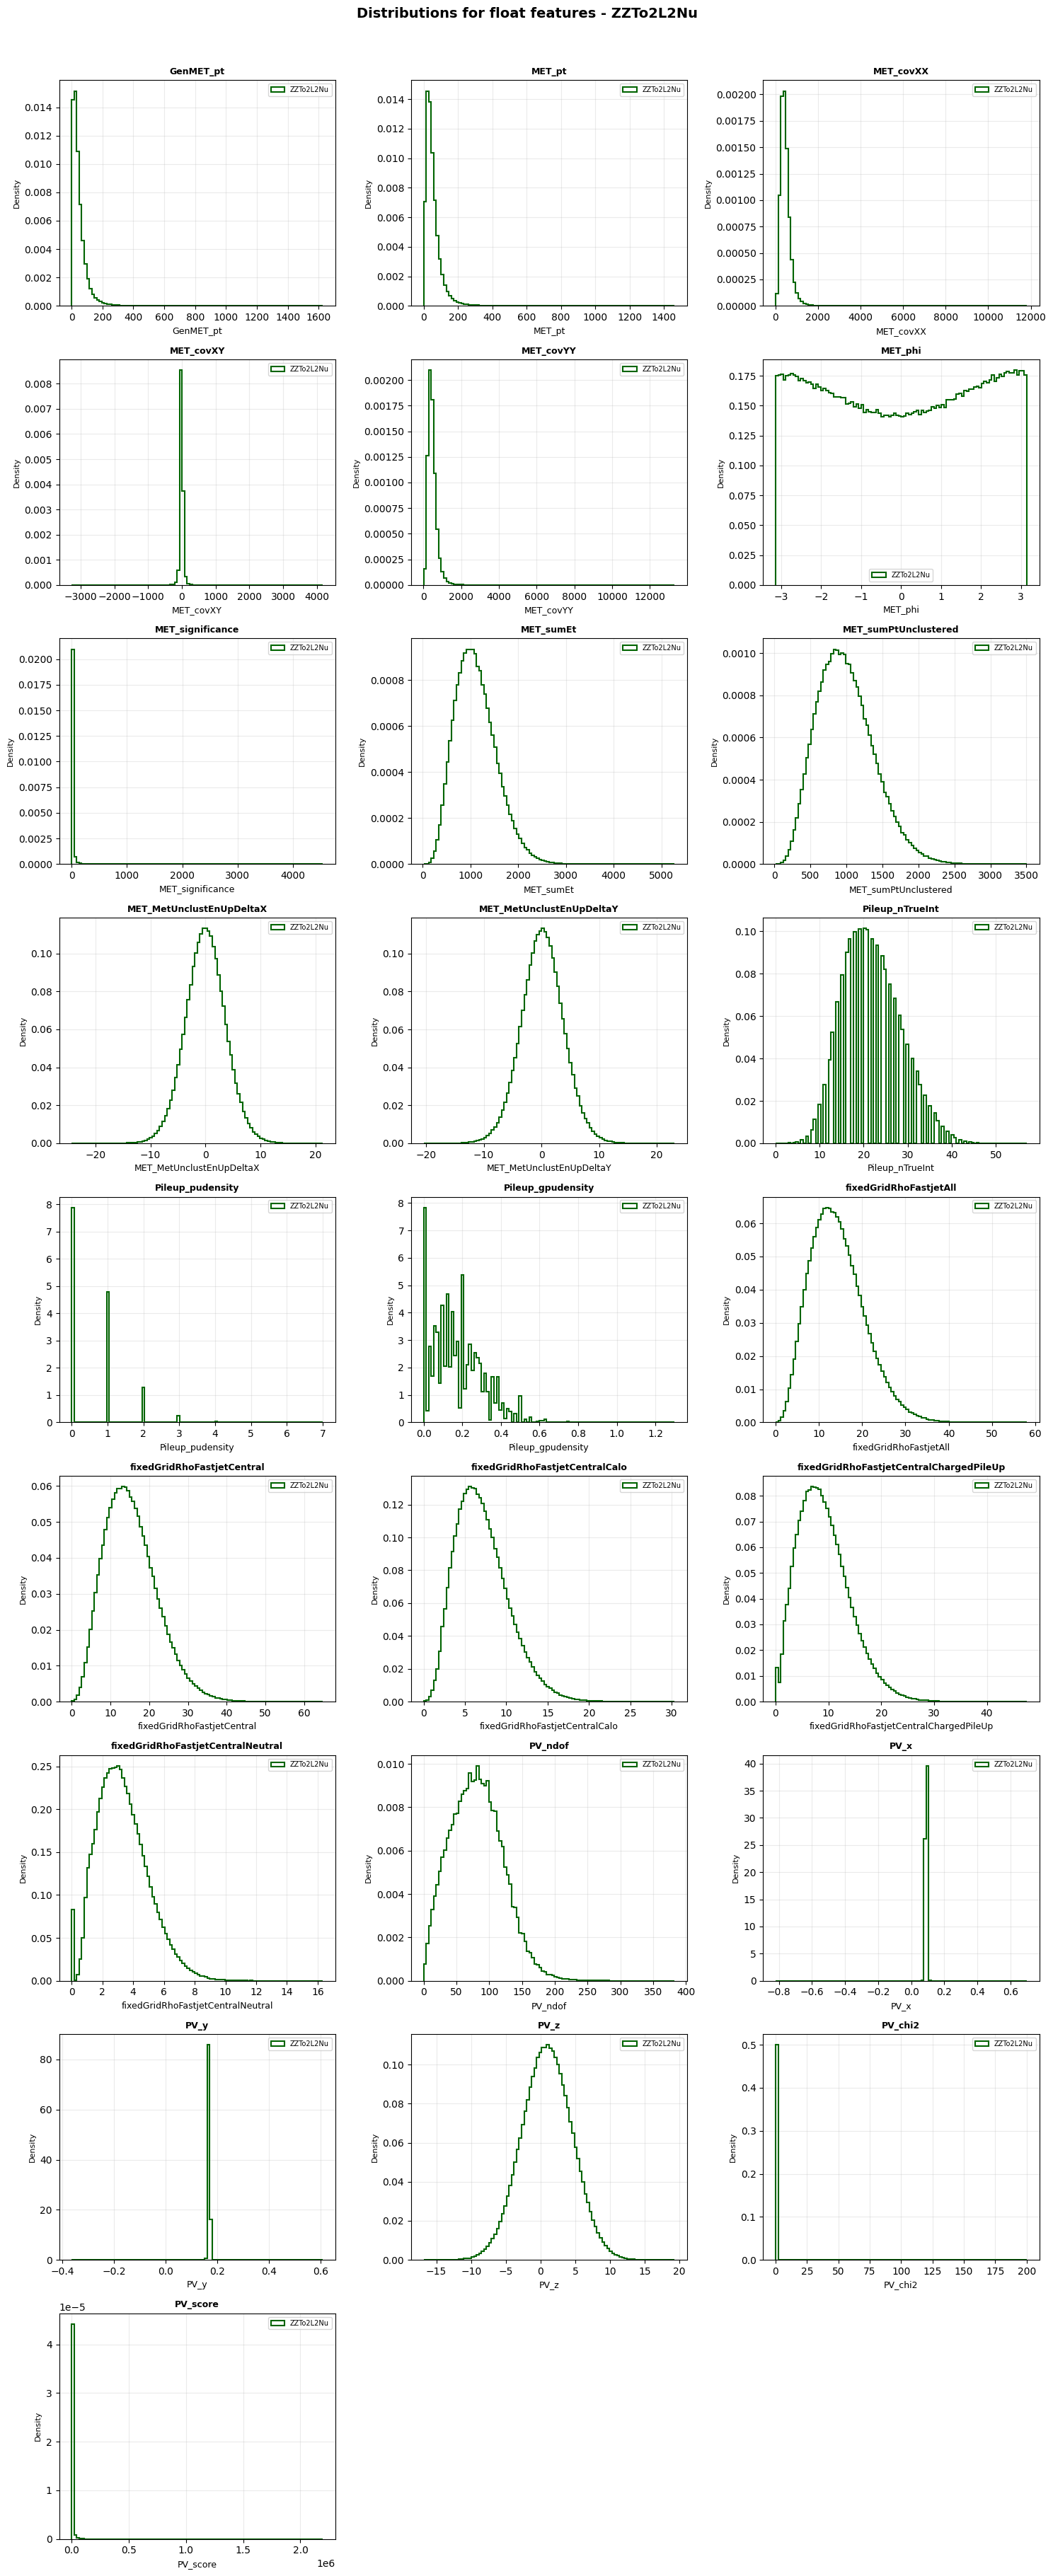

Outliers — ZZTo2L2Nu
  GenMET_pt             69511 outliers (5.41%)
  MET_pt                66596 outliers (5.18%)
  MET_covXX             44887 outliers (3.49%)
  MET_covXY            142197 outliers (11.07%)
  MET_covYY             45412 outliers (3.53%)
  MET_phi                   0 outliers (0.00%)
  MET_significance     132397 outliers (10.30%)
  MET_sumEt             14721 outliers (1.15%)
  MET_sumPtUnclustered  12586 outliers (0.98%)
  MET_MetUnclustEnUpDeltaX  15305 outliers (1.19%)
  MET_MetUnclustEnUpDeltaY  15220 outliers (1.18%)
  Pileup_nTrueInt        8316 outliers (0.65%)
  Pileup_pudensity      26640 outliers (2.07%)
  Pileup_gpudensity     11238 outliers (0.87%)
  fixedGridRhoFastjetAll  15113 outliers (1.18%)
  fixedGridRhoFastjetCentral  15144 outliers (1.18%)
  fixedGridRhoFastjetCentralCalo  18233 outliers (1.42%)
  fixedGridRhoFastjetCentralChargedPileUp  17719 outliers (1.38%)
  fixedGridRhoFastjetCentralNeutral  15257 outliers (1.19%)
  PV_ndof                7

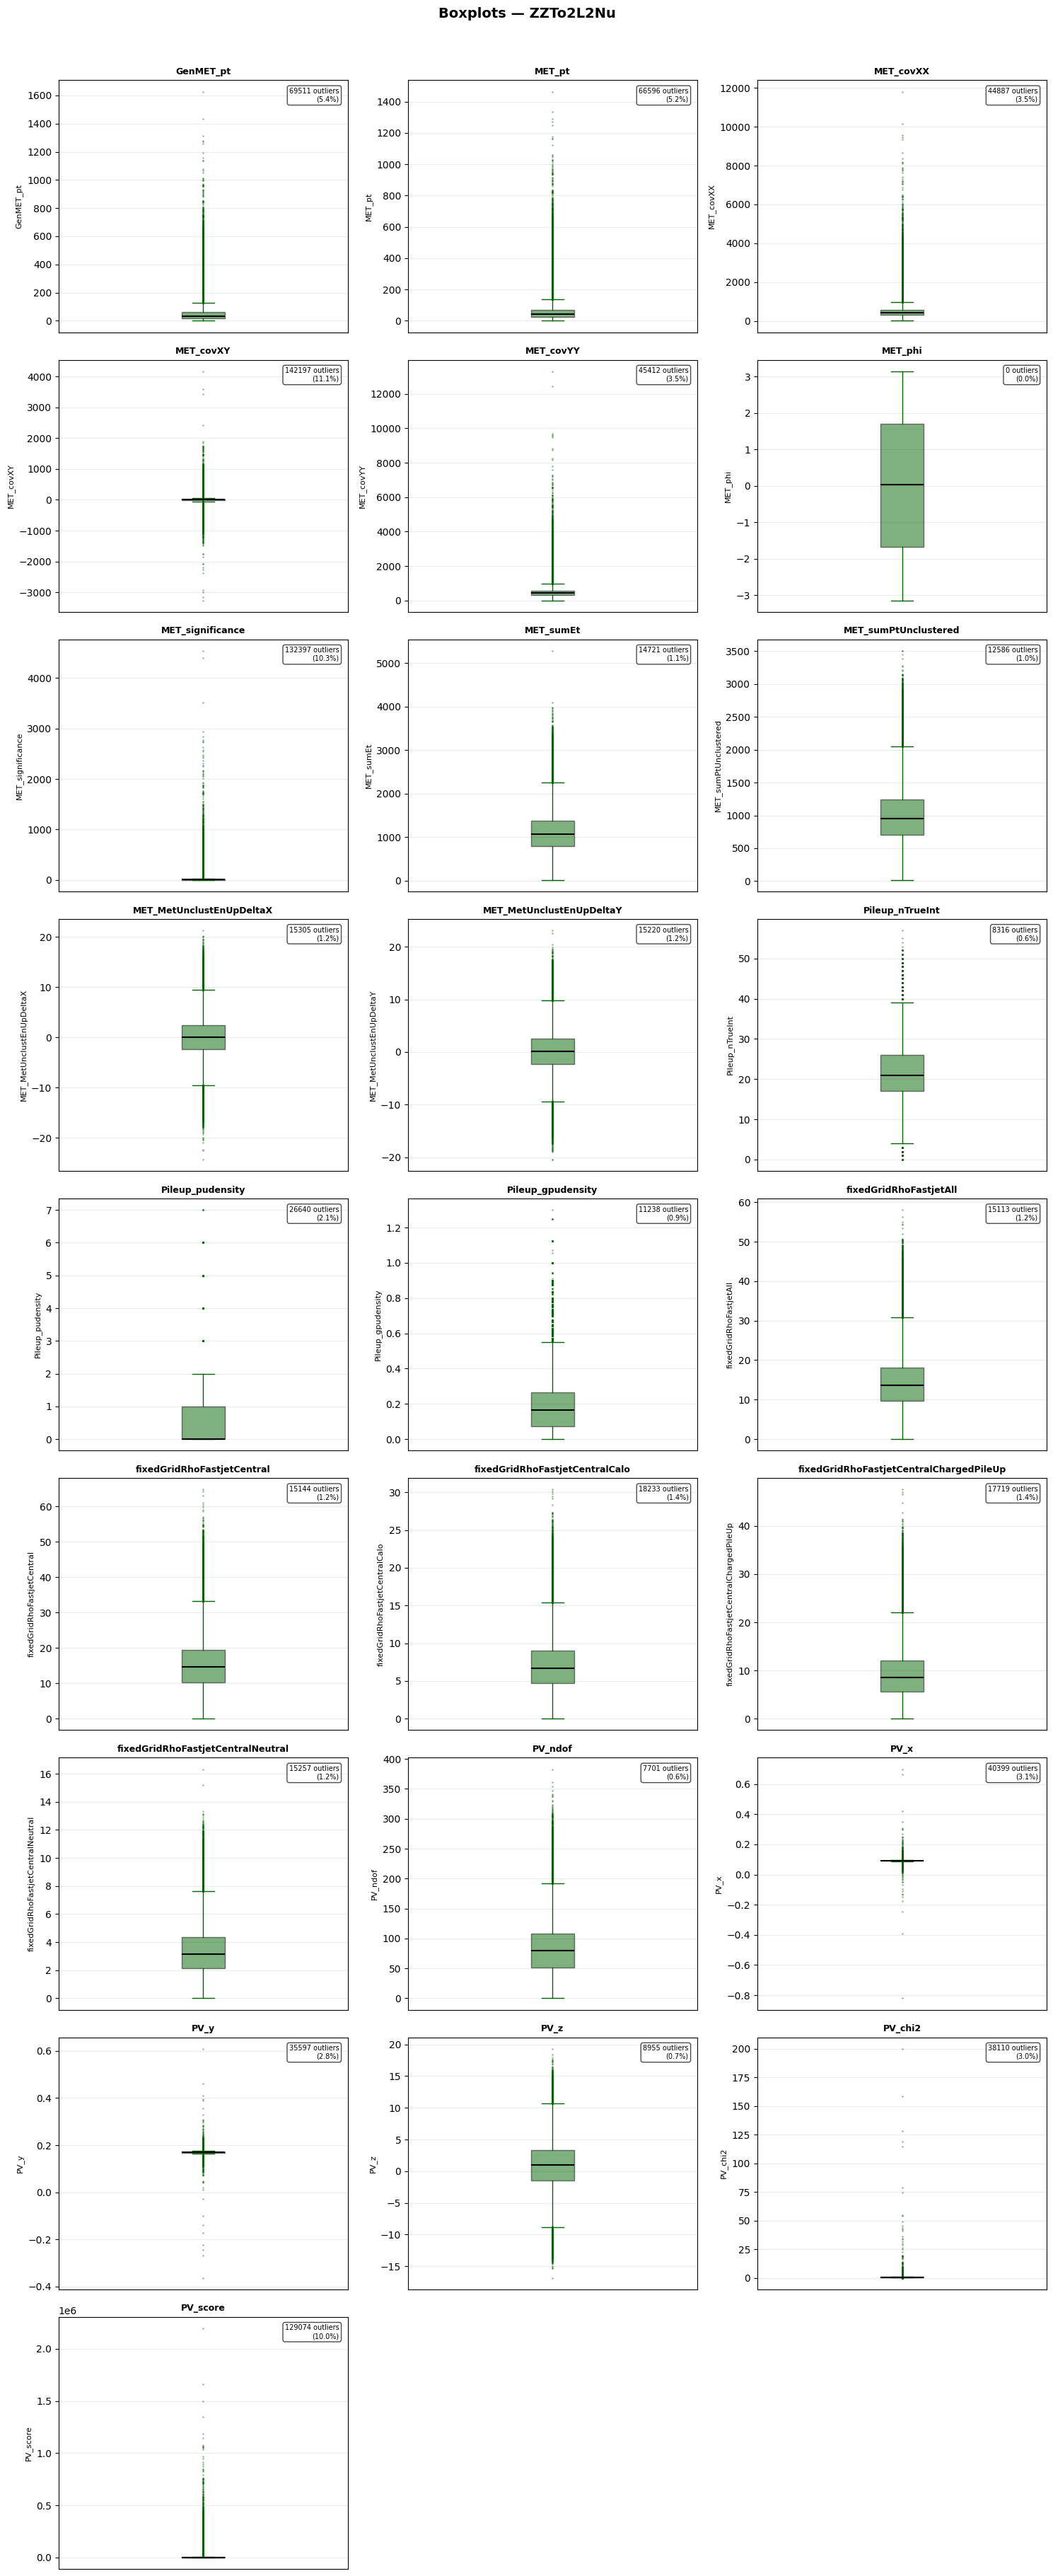

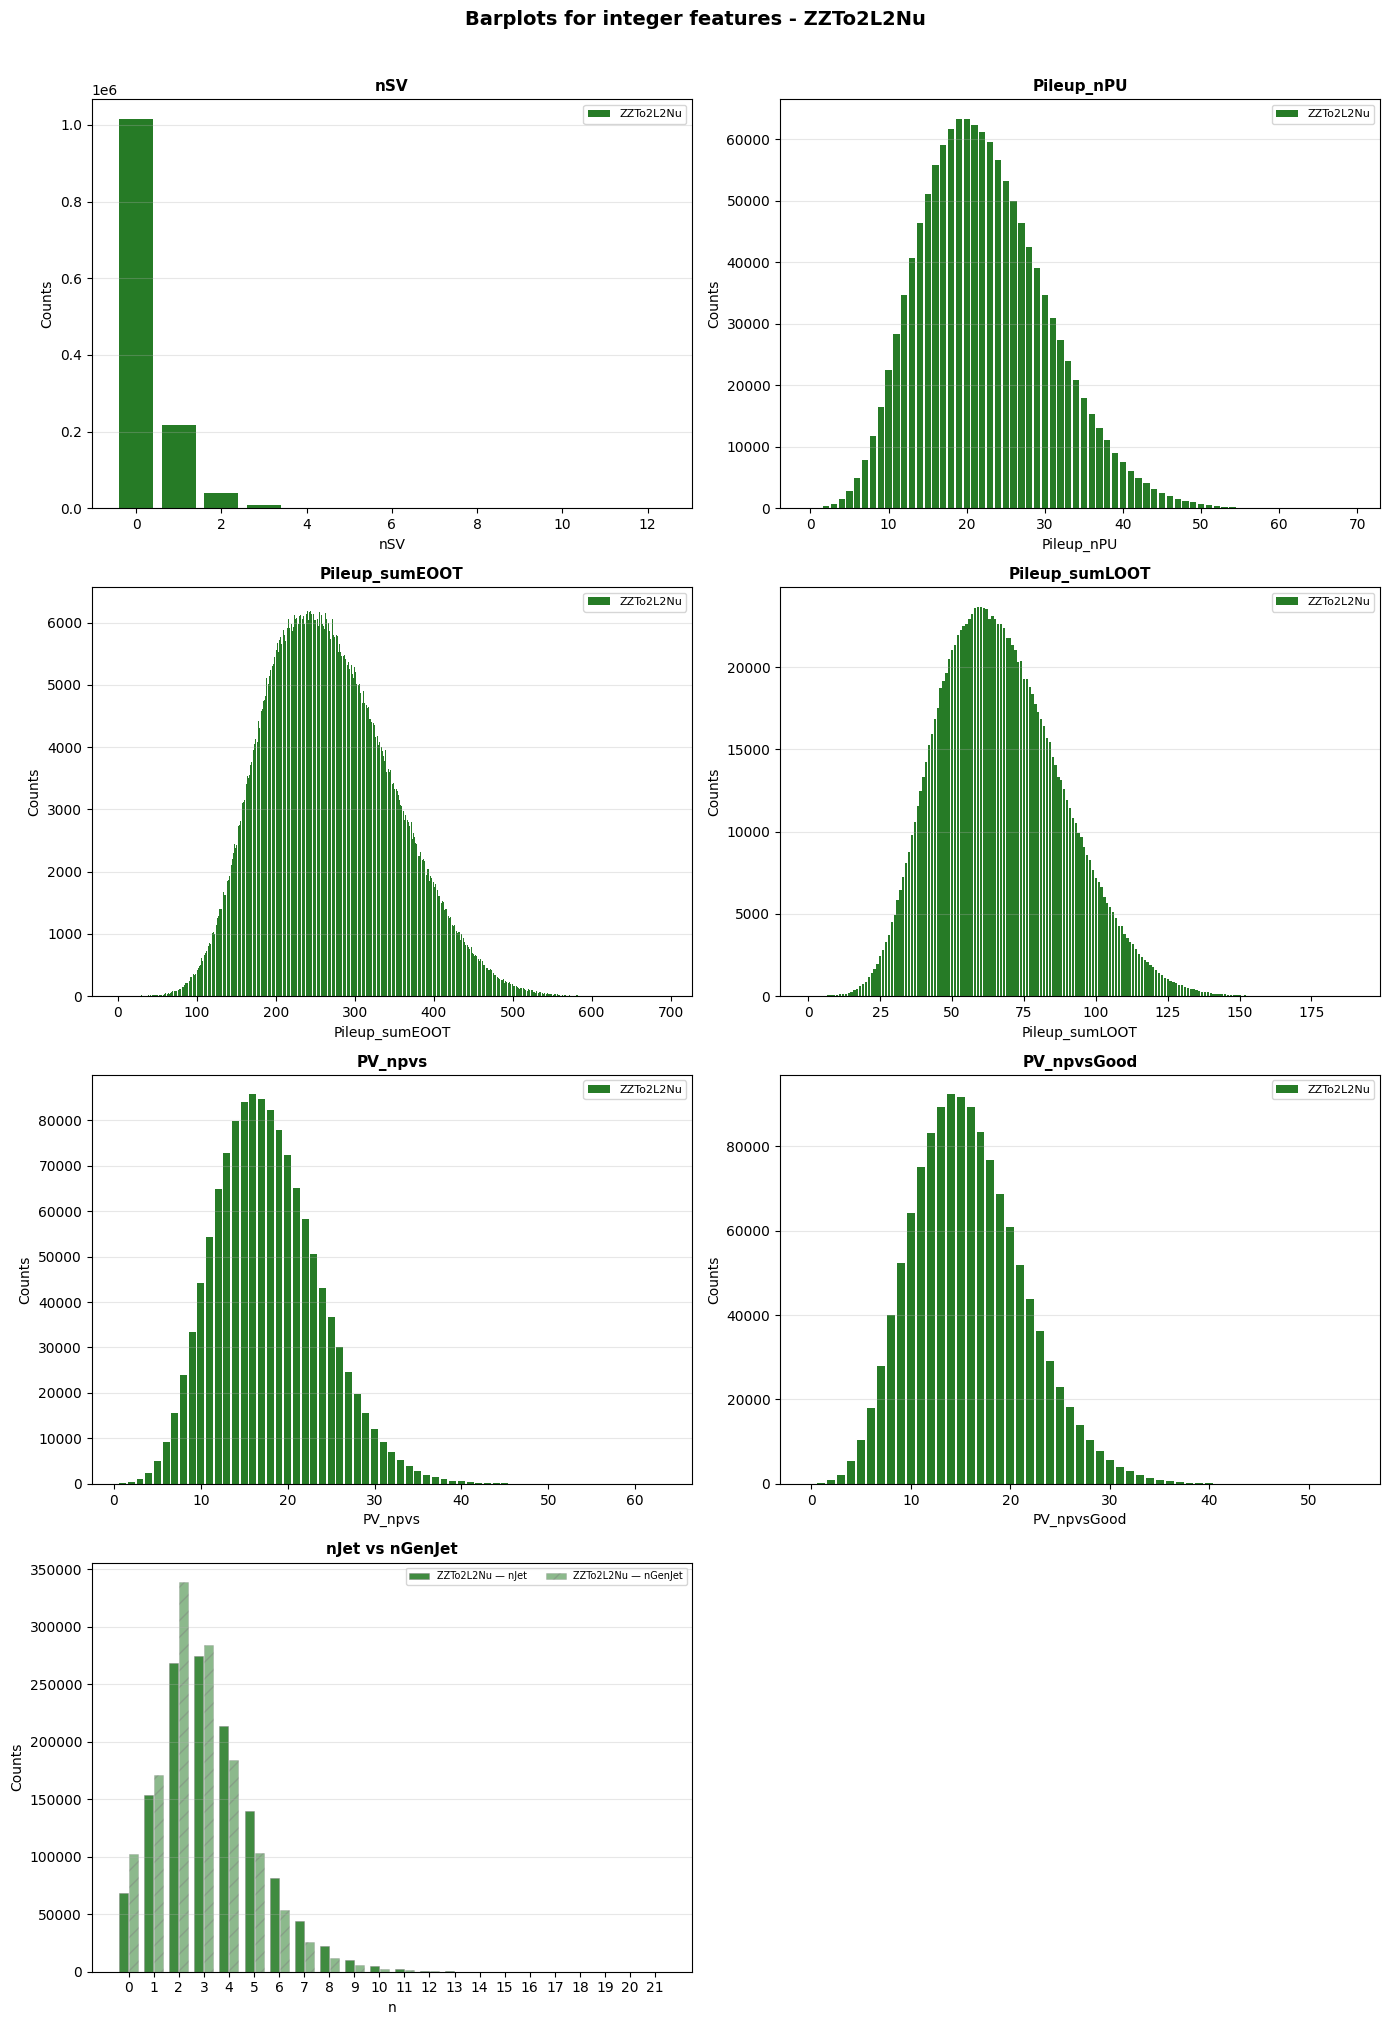

In [131]:
_correlation_heatmap(df, label)

_correlation_heatmap(df, label, method="spearman")

_scatterplot_MET(df, label=label, color=color)

_data_distributions(df, label=label, color=color)

_boxplots(df, label=label, color=color)

_data_barplots(df, label=label, color=color)

All observations are a direct consequence of the event composition, confirming that a cleaning step is necessary to remove events that do not match the expected signal signature.